# 🔍 AI-Based Customer Behavior Segmentation for Web Analytics
## Dataset: Google Analytics 4 (GA4) BigQuery Obfuscated Sample Ecommerce

---

### Project Overview
This notebook implements a complete end-to-end AI-based customer behavior segmentation system
using real-world web analytics data from Google's GA4 BigQuery public dataset.

The dataset comes from the **Google Merchandise Store** and contains obfuscated GA4 event-level
data covering **November 2020 – January 2021** (92 days) with user sessions, pageviews,
ecommerce events, and traffic source information.


### Table of Contents
```
Section 1  — Install Libraries
Section 2  — Google Authentication
Section 3  — Project Configuration
Section 4  — Data Extraction from BigQuery (GA4)
Section 5  — Data Overview & Schema Understanding
Section 6  — Exploratory Data Analysis (EDA)
Section 7  — Data Cleaning & Preprocessing
Section 8  — Feature Engineering
Section 9  — RFM Analysis
Section 10 — Dimensionality Reduction (PCA)
Section 11 — Finding Optimal Number of Clusters
Section 12 — K-Means Clustering
Section 13 — DBSCAN Clustering
Section 14 — Agglomerative Hierarchical Clustering
Section 15 — UMAP & t-SNE Visualization
Section 16 — Cluster Profiling & Segment Labeling
Section 17 — Segment Characterization & Business Insights
Section 18 — Predictive Classifier (Random Forest)
Section 19 — Model Evaluation
Section 20 — Feature Importance
Section 21 — Final Report & Marketing Recommendations
```

---
**Author:** Aditya Manoj , Anika Gupta
**Dataset:** `bigquery-public-data.ga4_obfuscated_sample_ecommerce`  
**Platform:** Google Colab

---
## Section 1: Install Libraries


In [ ]:
# ─────────────────────────────────────────────────────────────
#  INSTALL MISSING LIBRARIES
# ─────────────────────────────────────────────────────────────

!pip install umap-learn==0.5.7 --quiet
!pip install xgboost==2.1.3 --quiet
!pip install plotly==5.24.1 --quiet

print("✅ All libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.9/153.9 MB 4.8 MB/s eta 0:00:00
✅ All libraries installed successfully!


---
## Section 2: Google Authentication
Authenticates your Google account so BigQuery can be accessed.


In [ ]:
# ─────────────────────────────────────────────────────────────
#  GOOGLE AUTHENTICATION
#  Click the link that appears, sign in
# ─────────────────────────────────────────────────────────────

from google.colab import auth
auth.authenticate_user()
print("✅ Google authentication successful!")

✅ Google authentication successful!


---
## Section 3: Imports & Project Configuration


In [ ]:
# ─────────────────────────────────────────────────────────────
#  ALL IMPORTS
# ─────────────────────────────────────────────────────────────

import os
import warnings
import joblib
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

from google.cloud import bigquery

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    calinski_harabasz_score, silhouette_samples
)
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, learning_curve
)
from sklearn.metrics import classification_report, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2',
           '#937860','#DA8BC3','#8C8C8C','#CCB974','#64B5CD']

# ─────────────────────────────────────────────────────────────
#  PROJECT CONFIGURATION
# ─────────────────────────────────────────────────────────────

PROJECT_ID  = "sihhackathon-471320"   # ← CHANGE THIS
DATASET_ID  = "bigquery-public-data.ga4_obfuscated_sample_ecommerce"
DATE_START  = "20201101"
DATE_END    = "20210131"
RANDOM_SEED = 42
K_CLUSTERS  = 5

# All files saved to Colab local storage (/content/)
SAVE_PATH   = '/content/'
DATA_PATH   = SAVE_PATH + 'ga4_users.csv'
MODEL_PATH  = SAVE_PATH + 'rf_segment_classifier.pkl'
SCALER_PATH = SAVE_PATH + 'scaler.pkl'
PCA_PATH    = SAVE_PATH + 'pca.pkl'
RESULT_PATH = SAVE_PATH + 'ga4_segmentation_results.csv'
REPORT_PATH = SAVE_PATH + 'segment_report.csv'

FEATURE_COLS = [
    'total_sessions','total_pageviews','total_scrolls','active_days',
    'pages_per_session','avg_session_duration_secs','scroll_rate',
    'view_item_count','add_to_cart_count','begin_checkout_count',
    'purchase_count','cart_rate','checkout_rate','conversion_rate',
    'total_revenue','avg_order_value','total_items_purchased',
    'recency_days','is_new_user','device_encoded','medium_encoded'
]

LOG_COLS = [
    'total_sessions','total_pageviews','total_scrolls',
    'view_item_count','add_to_cart_count','purchase_count',
    'total_revenue','avg_order_value','total_items_purchased',
    'avg_session_duration_secs'
]

SEGMENT_NAMES = {
    0: 'High-Value Buyers',
    1: 'Engaged Non-Converters',
    2: 'At-Risk Churners',
    3: 'One-Time Visitors',
    4: 'Content Browsers'
}

# Initialize BigQuery client
client = bigquery.Client(project=PROJECT_ID)

print("✅ All imports successful!")
print(f"📦 Pandas  : {pd.__version__}")
print(f"📦 Numpy   : {np.__version__}")
print(f"📦 Sklearn : {__import__('sklearn').__version__}")
print(f"🔗 BigQuery project: {PROJECT_ID}")
print(f"💾 Save path: {SAVE_PATH}")

✅ All imports successful!
📦 Pandas  : 2.2.2
📦 Numpy   : 2.0.2
📦 Sklearn : 1.6.1
🔗 BigQuery project: sihhackathon-471320
💾 Save path: /content/


---
## Section 4: Data Extraction from BigQuery (GA4)

We extract user-level behavioral features by aggregating raw GA4 event rows.
Results are cached to Google Drive so BigQuery is only queried once.

**Key events captured:**
`page_view`, `scroll`, `view_item`, `add_to_cart`, `begin_checkout`, `purchase`, `first_visit`

In [ ]:
# ─────────────────────────────────────────────────────────────
#  DATA EXTRACTION FROM GA4 BIGQUERY
#  Cached to Drive — BigQuery only queried on first run
# ─────────────────────────────────────────────────────────────

def extract_ga4_user_features(force_refresh=False):
    if os.path.exists(DATA_PATH) and not force_refresh:
        print(f"📂 Loading cached data from Drive...")
        df = pd.read_csv(DATA_PATH)
        print(f"✅ Loaded {len(df):,} users from cache.")
        return df

    print("🔄 Querying BigQuery... (takes 1-2 minutes)")

    query = f"""
    WITH raw_events AS (
      SELECT
        user_pseudo_id,
        event_name,
        event_date,
        event_timestamp,
        (SELECT value.int_value FROM UNNEST(event_params)
         WHERE key = 'ga_session_id')              AS session_id,
        (SELECT value.int_value FROM UNNEST(event_params)
         WHERE key = 'ga_session_number')          AS session_number,
        (SELECT value.string_value FROM UNNEST(event_params)
         WHERE key = 'page_location')              AS page_location,
        (SELECT value.int_value FROM UNNEST(event_params)
         WHERE key = 'engagement_time_msec')       AS engagement_time_msec,
        ecommerce.purchase_revenue                 AS purchase_revenue,
        ecommerce.unique_items                     AS unique_items,
        traffic_source.source                      AS traffic_source,
        traffic_source.medium                      AS traffic_medium,
        device.category                            AS device_category,
        device.web_info.browser                             AS browser,
        device.operating_system                    AS operating_system,
        geo.country                                AS country,
        geo.city                                   AS city,
        user_ltv.revenue                           AS ltv_revenue
      FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
      WHERE _TABLE_SUFFIX BETWEEN '{DATE_START}' AND '{DATE_END}'
    ),
    user_agg AS (
      SELECT
        user_pseudo_id,
        COUNT(DISTINCT session_id)                 AS total_sessions,
        MAX(session_number)                        AS max_session_number,
        COUNTIF(event_name = 'page_view')          AS total_pageviews,
        COUNTIF(event_name = 'scroll')             AS total_scrolls,
        COUNTIF(event_name = 'user_engagement')    AS total_engagements,
        SUM(engagement_time_msec) / 1000.0         AS total_engagement_secs,
        COUNTIF(event_name = 'view_item')          AS view_item_count,
        COUNTIF(event_name = 'view_item_list')     AS view_item_list_count,
        COUNTIF(event_name = 'select_item')        AS select_item_count,
        COUNTIF(event_name = 'add_to_cart')        AS add_to_cart_count,
        COUNTIF(event_name = 'remove_from_cart')   AS remove_from_cart_count,
        COUNTIF(event_name = 'begin_checkout')     AS begin_checkout_count,
        COUNTIF(event_name = 'add_payment_info')   AS add_payment_info_count,
        COUNTIF(event_name = 'purchase')           AS purchase_count,
        COALESCE(SUM(purchase_revenue), 0)         AS total_revenue,
        COALESCE(AVG(purchase_revenue), 0)         AS avg_order_value,
        COALESCE(SUM(unique_items), 0)             AS total_items_purchased,
        MAX(ltv_revenue)                           AS ltv_revenue,
        MAX(PARSE_DATE('%Y%m%d', event_date))      AS last_active_date,
        MIN(PARSE_DATE('%Y%m%d', event_date))      AS first_active_date,
        COUNT(DISTINCT event_date)                 AS active_days,
        MAX(IF(event_name = 'first_visit', 1, 0))  AS is_new_user,
        APPROX_TOP_COUNT(traffic_medium, 1)[OFFSET(0)].value   AS primary_medium,
        APPROX_TOP_COUNT(device_category, 1)[OFFSET(0)].value  AS primary_device,
        APPROX_TOP_COUNT(country, 1)[OFFSET(0)].value          AS primary_country,
        APPROX_TOP_COUNT(browser, 1)[OFFSET(0)].value          AS primary_browser
      FROM raw_events
      GROUP BY user_pseudo_id
    )
    SELECT *,
      SAFE_DIVIDE(total_pageviews, total_sessions)           AS pages_per_session,
      SAFE_DIVIDE(total_engagement_secs, total_sessions)     AS avg_session_duration_secs,
      SAFE_DIVIDE(total_scrolls, total_pageviews)            AS scroll_rate,
      SAFE_DIVIDE(add_to_cart_count, view_item_count)        AS cart_rate,
      SAFE_DIVIDE(begin_checkout_count, add_to_cart_count)   AS checkout_rate,
      SAFE_DIVIDE(purchase_count, begin_checkout_count)      AS purchase_completion_rate,
      SAFE_DIVIDE(purchase_count, total_sessions)            AS conversion_rate,
      DATE_DIFF(DATE '2021-01-31', last_active_date, DAY)    AS recency_days,
      active_days                                            AS frequency
    FROM user_agg
    WHERE total_sessions > 0
    ORDER BY total_revenue DESC
    """

    df = client.query(query).to_dataframe()
    df.to_csv(DATA_PATH, index=False)
    print(f"✅ Extracted {len(df):,} users with {df.shape[1]} features")
    print(f"💾 Saved to Drive: {DATA_PATH}")
    return df


df_raw = extract_ga4_user_features(force_refresh=False)
print(f"\nDataset shape: {df_raw.shape}")
df_raw.head()

🔄 Querying BigQuery... (takes 1-2 minutes)
✅ Extracted 270,154 users with 36 features
💾 Saved to Drive: /content/ga4_users.csv

Dataset shape: (270154, 36)


,user_pseudo_id,total_sessions,max_session_number,total_pageviews,total_scrolls,total_engagements,total_engagement_secs,view_item_count,view_item_list_count,select_item_count,add_to_cart_count,remove_from_cart_count,begin_checkout_count,add_payment_info_count,purchase_count,total_revenue,avg_order_value,total_items_purchased,ltv_revenue,last_active_date,first_active_date,active_days,is_new_user,primary_medium,primary_device,primary_country,primary_browser,pages_per_session,avg_session_duration_secs,scroll_rate,cart_rate,checkout_rate,purchase_completion_rate,conversion_rate,recency_days,frequency
0,81036435.1157569602,10,12,191,84,181,4974.7880,75,0,10,3,0,20,2,1,1530.0000,1530.0000,909,1530.0000,2020-12-22,2020-11-06,8,0,organic,desktop,Australia,Chrome,19.1000,497.4788,0.4398,0.0400,6.6667,0.0500,0.1000,40,8
1,15046526.4562004600,2,2,52,25,48,1877.1750,25,0,3,0,0,12,5,3,1424.0000,474.6667,293,1424.0000,2020-12-31,2020-12-30,2,1,referral,desktop,United States,Chrome,26.0000,938.5875,0.4808,0.0000,NaN,0.2500,1.5000,31,2
2,8083450.3844124226,9,9,219,96,204,4364.8250,72,0,15,3,0,38,16,11,1404.0000,127.6364,738,1409.0000,2020-12-15,2020-12-09,4,1,(none),desktop,Canada,Chrome,24.3333,484.9806,0.4384,0.0417,12.6667,0.2895,1.2222,47,4
3,60695124.4742262801,11,11,160,79,146,3130.3010,78,0,7,15,0,22,10,5,1260.0000,252.0000,944,1260.0000,2020-12-10,2020-11-12,6,1,(data deleted),mobile,India,Android Webview,14.5455,284.5728,0.4938,0.1923,1.4667,0.2273,0.4545,52,6
4,7134559299.4601048201,4,4,32,13,31,874.0590,6,0,0,20,0,9,2,1,1200.0000,1200.0000,161,1200.0000,2021-01-19,2021-01-18,2,1,(none),mobile,Canada,Android Webview,8.0000,218.5147,0.4062,3.3333,0.4500,0.1111,0.2500,12,2


---
## Section 5: Data Overview & Schema Understanding

In [ ]:
# ─────────────────────────────────────────────────────────────
#  DATA OVERVIEW
# ─────────────────────────────────────────────────────────────

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total Users    : {len(df_raw):,}")
print(f"Total Features : {df_raw.shape[1]}")
print(f"Memory Usage   : {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print()

print("─" * 40)
print("MISSING VALUES")
print("─" * 40)
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print()

print("─" * 40)
print("BASIC STATISTICS")
print("─" * 40)
display(df_raw.describe().T)

DATASET OVERVIEW
Total Users    : 270,154
Total Features : 36
Memory Usage   : 144.00 MB

────────────────────────────────────────
MISSING VALUES
────────────────────────────────────────
                           Missing Count  Missing %
total_engagement_secs              31808    11.7700
avg_session_duration_secs          31808    11.7700
scroll_rate                          362     0.1300
cart_rate                         208902    77.3300
checkout_rate                     257609    95.3600
purchase_completion_rate          260439    96.4000

────────────────────────────────────────
BASIC STATISTICS
────────────────────────────────────────


,count,mean,std,min,25%,50%,75%,max
total_sessions,270154.0000,1.3331,1.0029,1.0000,1.0000,1.0000,1.0000,12.0000
max_session_number,270154.0000,1.4509,1.7035,1.0000,1.0000,1.0000,1.0000,154.0000
total_pageviews,270154.0000,4.9987,12.7644,0.0000,1.0000,2.0000,4.0000,566.0000
total_scrolls,270154.0000,1.8252,5.2141,0.0000,0.0000,1.0000,1.0000,173.0000
total_engagements,270154.0000,3.9190,11.9296,0.0000,1.0000,1.0000,3.0000,469.0000
total_engagement_secs,238346.0000,106.2878,420.0395,0.0010,4.7710,14.3000,59.5735,70799.0110
view_item_count,270154.0000,1.4291,6.4418,0.0000,0.0000,0.0000,0.0000,330.0000
view_item_list_count,270154.0000,0.0003,0.0296,0.0000,0.0000,0.0000,0.0000,9.0000
select_item_count,270154.0000,0.1148,0.8421,0.0000,0.0000,0.0000,0.0000,55.0000
add_to_cart_count,270154.0000,0.2167,1.7992,0.0000,0.0000,0.0000,0.0000,98.0000


In [ ]:
# ─────────────────────────────────────────────────────────────
#  CATEGORICAL COLUMNS OVERVIEW
# ─────────────────────────────────────────────────────────────

cat_cols = ['primary_medium', 'primary_device', 'primary_country', 'primary_browser']

for col in cat_cols:
    print(f"\n── {col} ──")
    vc = df_raw[col].value_counts()
    print(vc.head(10).to_string())
    print(f"   Unique values: {df_raw[col].nunique()}")


── primary_medium ──
primary_medium
organic           99979
(none)            63776
<Other>           45509
referral          41548
cpc               13678
(data deleted)     5664
   Unique values: 6

── primary_device ──
primary_device
desktop    156955
mobile     107140
tablet       6059
   Unique values: 3

── primary_country ──
primary_country
United States     118493
India              25367
Canada             20268
United Kingdom      8527
France              5381
Spain               5044
Germany             4866
China               4620
Taiwan              4568
Italy               3750
   Unique values: 109

── primary_browser ──
primary_browser
Chrome             183754
Safari              64819
<Other>              7001
Edge                 5995
Firefox              5083
Android Webview      3502
   Unique values: 6


---
## Section 6: Exploratory Data Analysis (EDA)

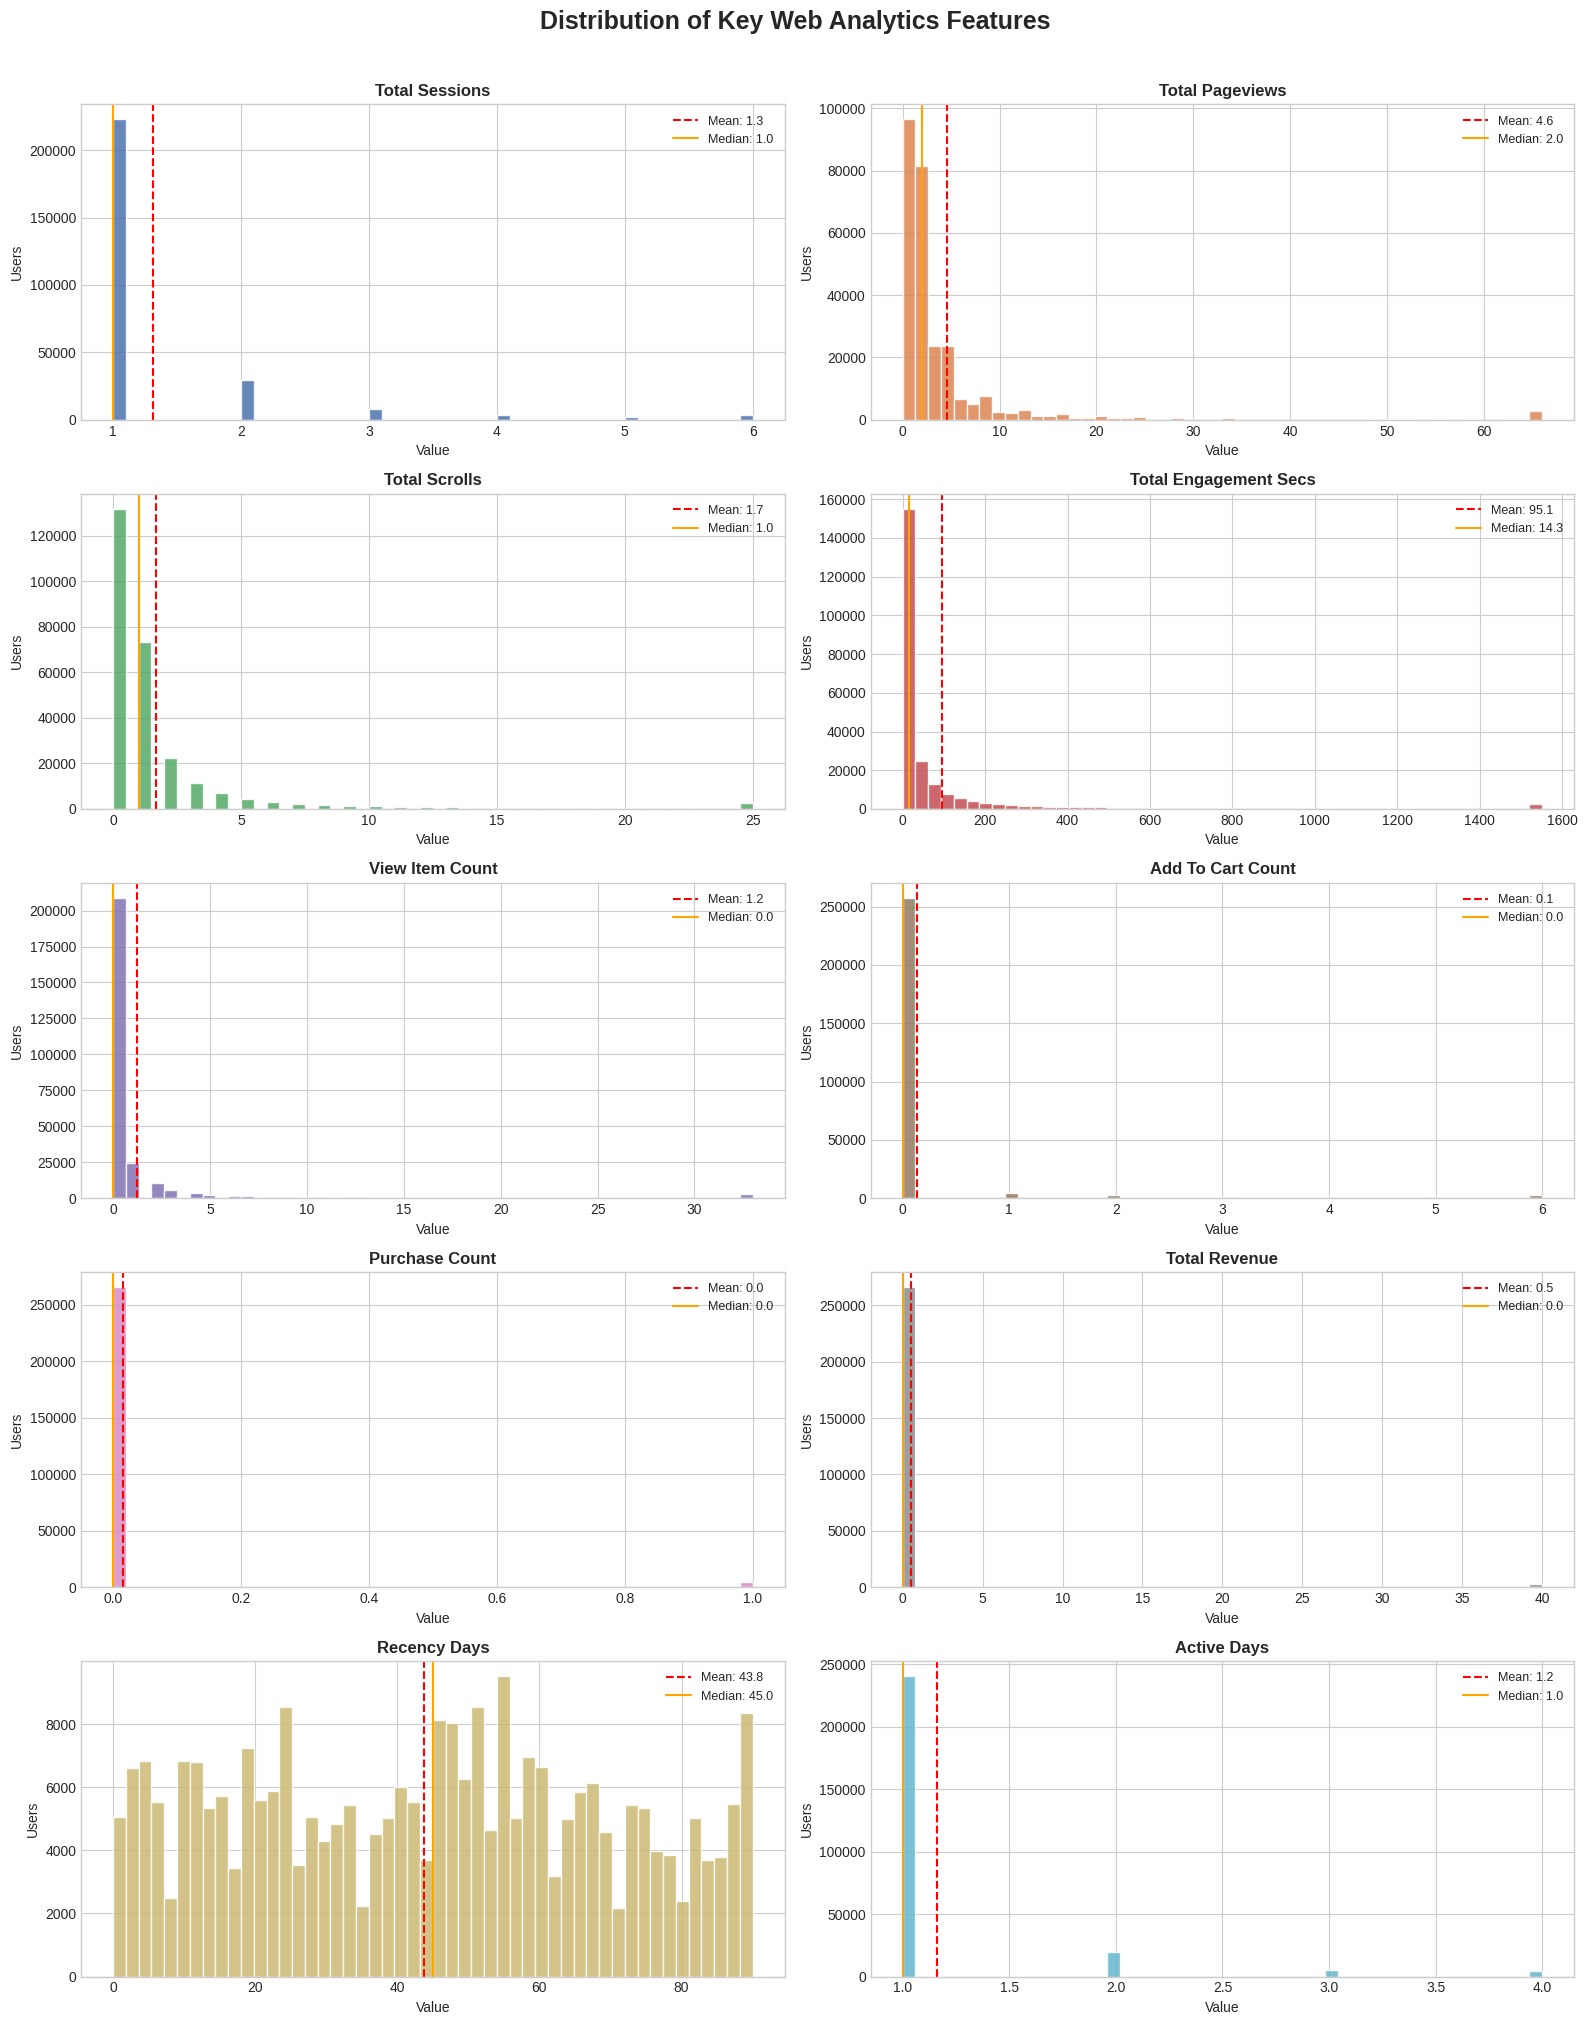

Note: values clipped at 99th percentile for clarity


In [ ]:
# ─────────────────────────────────────────────────────────────
#  EDA 1: DISTRIBUTION OF KEY NUMERIC FEATURES
# ─────────────────────────────────────────────────────────────

numeric_features = [
    'total_sessions','total_pageviews','total_scrolls',
    'total_engagement_secs','view_item_count','add_to_cart_count',
    'purchase_count','total_revenue','recency_days','active_days'
]

fig, axes = plt.subplots(5, 2, figsize=(16, 20))
fig.suptitle('Distribution of Key Web Analytics Features', fontsize=18, fontweight='bold', y=1.01)

for idx, (col, ax) in enumerate(zip(numeric_features, axes.flatten())):
    data = df_raw[col].clip(upper=df_raw[col].quantile(0.99))
    ax.hist(data, bins=50, color=PALETTE[idx % len(PALETTE)], edgecolor='white', alpha=0.85)
    ax.set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Users')
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='orange', linestyle='-',  linewidth=1.5, label=f'Median: {data.median():.1f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(SAVE_PATH + 'eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Note: values clipped at 99th percentile for clarity")

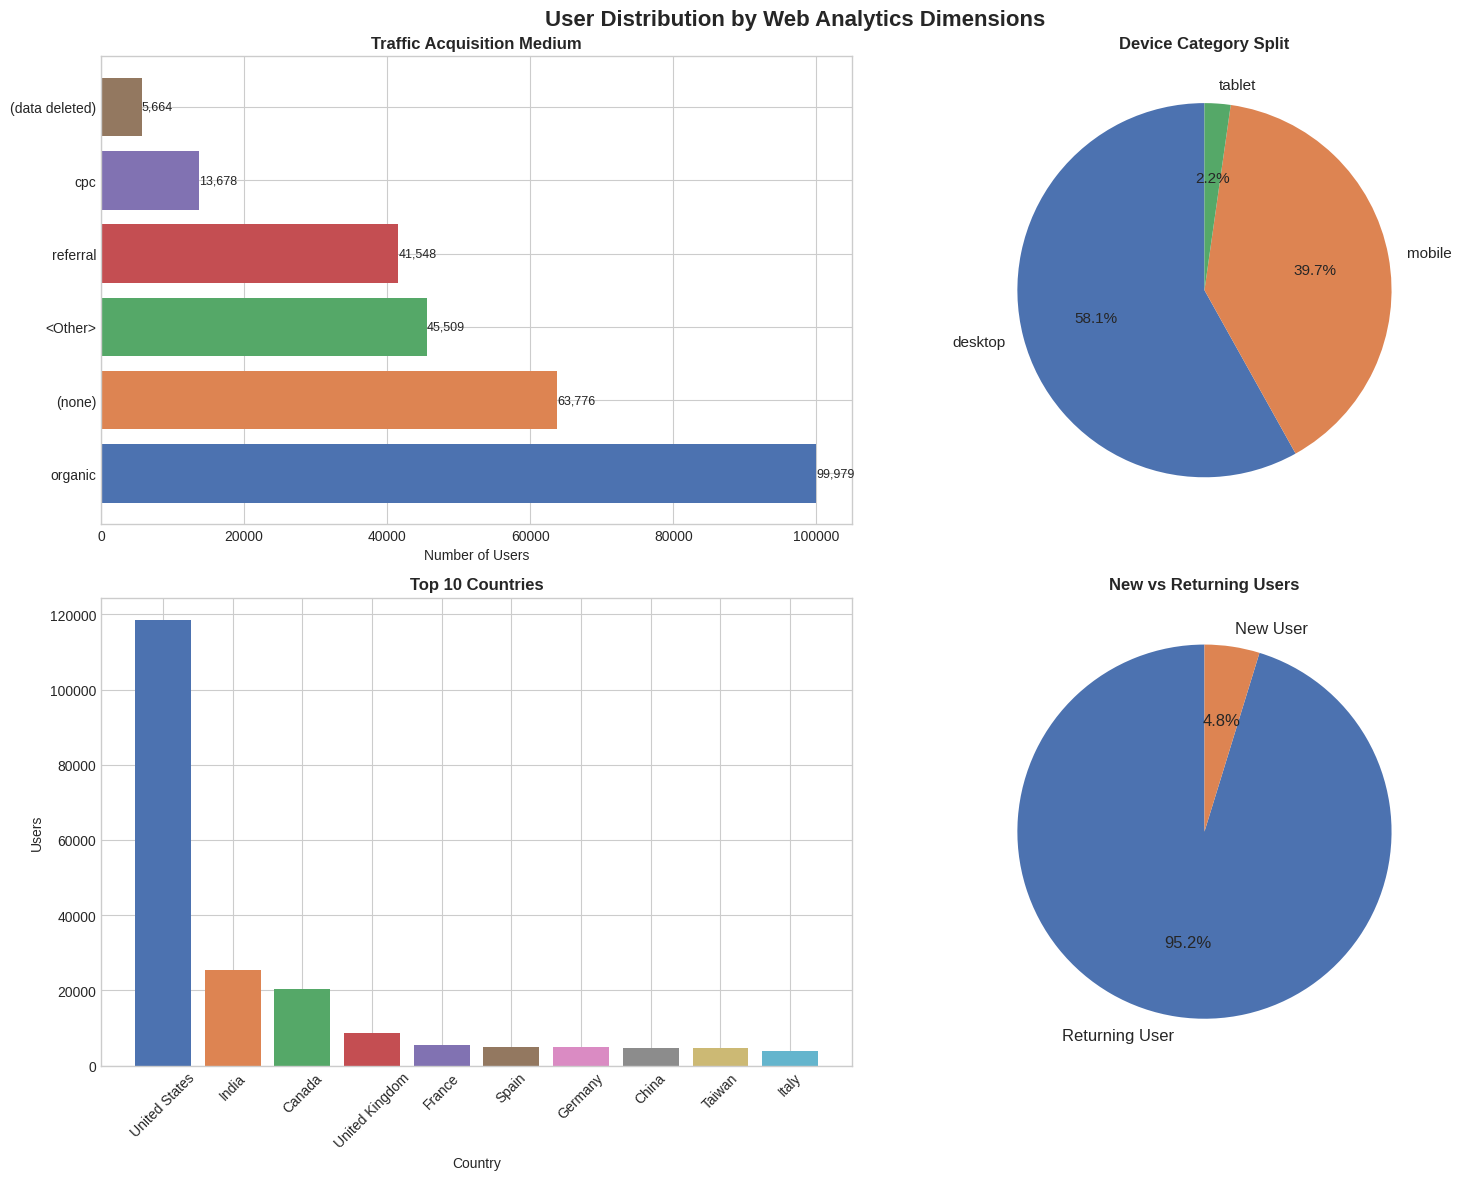

In [ ]:
# ─────────────────────────────────────────────────────────────
#  EDA 2: CATEGORICAL BREAKDOWNS
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('User Distribution by Web Analytics Dimensions', fontsize=16, fontweight='bold')

med_counts = df_raw['primary_medium'].value_counts().head(8)
axes[0,0].barh(med_counts.index, med_counts.values, color=PALETTE)
axes[0,0].set_title('Traffic Acquisition Medium', fontweight='bold')
axes[0,0].set_xlabel('Number of Users')
for i, v in enumerate(med_counts.values):
    axes[0,0].text(v + 5, i, f'{v:,}', va='center', fontsize=9)

dev_counts = df_raw['primary_device'].value_counts()
axes[0,1].pie(dev_counts.values, labels=dev_counts.index,
              colors=PALETTE[:len(dev_counts)], autopct='%1.1f%%',
              startangle=90, textprops={'fontsize': 11})
axes[0,1].set_title('Device Category Split', fontweight='bold')

cty_counts = df_raw['primary_country'].value_counts().head(10)
axes[1,0].bar(cty_counts.index, cty_counts.values, color=PALETTE)
axes[1,0].set_title('Top 10 Countries', fontweight='bold')
axes[1,0].set_xlabel('Country')
axes[1,0].set_ylabel('Users')
axes[1,0].tick_params(axis='x', rotation=45)

new_user_pct = df_raw['is_new_user'].value_counts()
axes[1,1].pie(new_user_pct.values,
              labels=['Returning User','New User'] if 0 in new_user_pct.index else ['New User'],
              colors=['#4C72B0','#DD8452'], autopct='%1.1f%%',
              startangle=90, textprops={'fontsize': 12})
axes[1,1].set_title('New vs Returning Users', fontweight='bold')

plt.tight_layout()
plt.savefig(SAVE_PATH + 'eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

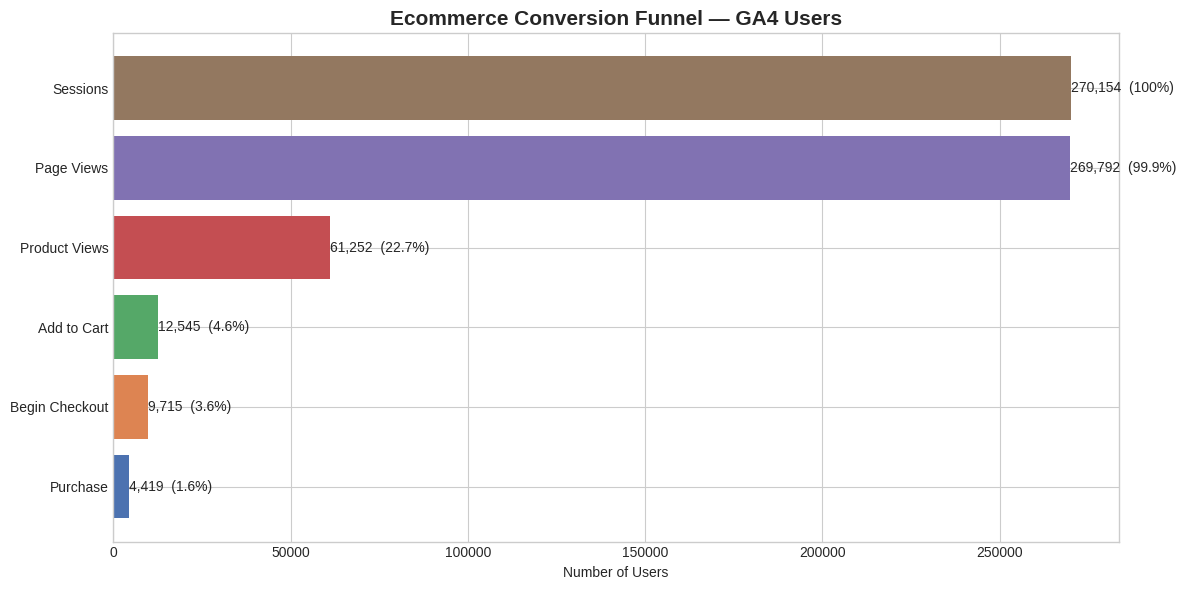


Funnel Drop-off:
  Sessions → Page Views: 0.1% drop-off
  Page Views → Product Views: 77.3% drop-off
  Product Views → Add to Cart: 79.5% drop-off
  Add to Cart → Begin Checkout: 22.6% drop-off
  Begin Checkout → Purchase: 54.5% drop-off


In [ ]:
# ─────────────────────────────────────────────────────────────
#  EDA 3: ECOMMERCE CONVERSION FUNNEL
# ─────────────────────────────────────────────────────────────

funnel_stages = {
    'Sessions'      : df_raw['total_sessions'].gt(0).sum(),
    'Page Views'    : df_raw['total_pageviews'].gt(0).sum(),
    'Product Views' : df_raw['view_item_count'].gt(0).sum(),
    'Add to Cart'   : df_raw['add_to_cart_count'].gt(0).sum(),
    'Begin Checkout': df_raw['begin_checkout_count'].gt(0).sum(),
    'Purchase'      : df_raw['purchase_count'].gt(0).sum()
}

stages = list(funnel_stages.keys())
counts = list(funnel_stages.values())
drop_rates = [100] + [round(counts[i]/counts[0]*100, 1) for i in range(1, len(counts))]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(stages[::-1], counts[::-1], color=PALETTE[:len(stages)])
ax.set_title('Ecommerce Conversion Funnel — GA4 Users', fontsize=15, fontweight='bold')
ax.set_xlabel('Number of Users')

for bar, count, rate in zip(bars, counts[::-1], drop_rates[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{count:,}  ({rate}%)', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(SAVE_PATH + 'eda_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFunnel Drop-off:")
for i in range(1, len(stages)):
    drop = round((1 - counts[i]/counts[i-1]) * 100, 1)
    print(f"  {stages[i-1]} → {stages[i]}: {drop}% drop-off")

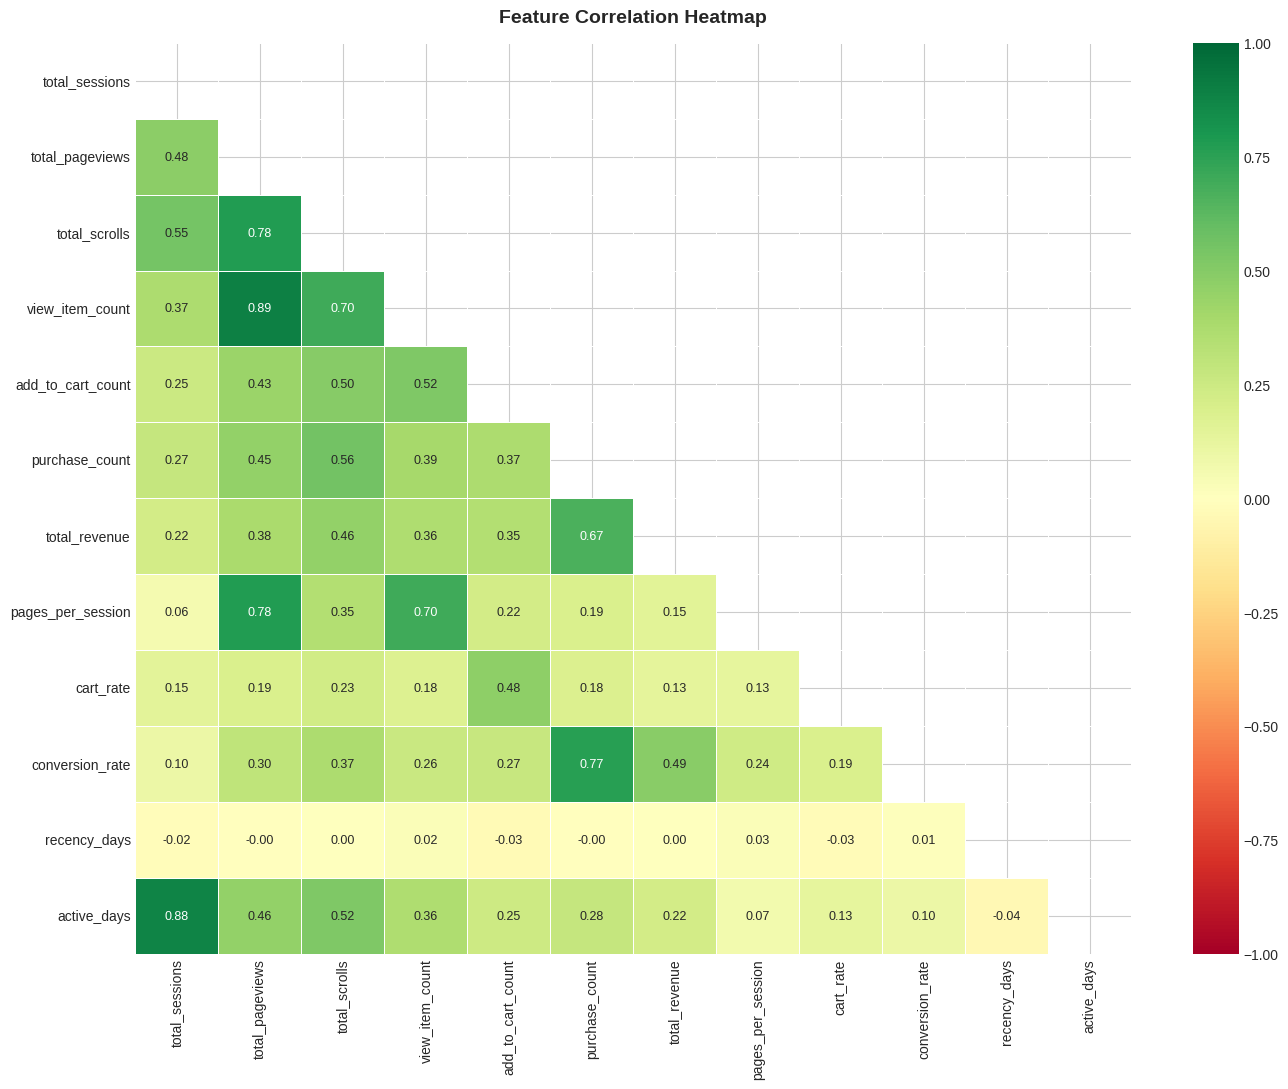

In [ ]:
# ─────────────────────────────────────────────────────────────
#  EDA 4: CORRELATION HEATMAP
# ─────────────────────────────────────────────────────────────

corr_cols = [
    'total_sessions','total_pageviews','total_scrolls',
    'view_item_count','add_to_cart_count','purchase_count',
    'total_revenue','pages_per_session','cart_rate',
    'conversion_rate','recency_days','active_days'
]

corr_matrix = df_raw[corr_cols].fillna(0).corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 7: Data Cleaning & Preprocessing

In [ ]:
# ─────────────────────────────────────────────────────────────
#  DATA CLEANING
# ─────────────────────────────────────────────────────────────

df = df_raw.copy()

print("Step 1: Handling missing values...")
numeric_cols  = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_all  = df.select_dtypes(include=['object']).columns.tolist()
df[numeric_cols]  = df[numeric_cols].fillna(0)
df[cat_cols_all]  = df[cat_cols_all].fillna('unknown')
print(f"   Remaining nulls: {df.isnull().sum().sum()}")

print("\nStep 2: Removing bots and extreme outliers...")
before = len(df)
df = df[
    (df['total_sessions']  <= df['total_sessions'].quantile(0.999)) &
    (df['total_pageviews'] <= df['total_pageviews'].quantile(0.999)) &
    (df['total_revenue']   <= df['total_revenue'].quantile(0.999)) &
    (df['total_sessions']  >= 1)
]
print(f"   Removed {before - len(df):,} outlier users. Remaining: {len(df):,}")

print("\nStep 3: Clipping negatives...")
for col in numeric_cols:
    df[col] = df[col].clip(lower=0)

print("\nStep 4: Encoding categorical features...")
le = LabelEncoder()
df['device_encoded']  = le.fit_transform(df['primary_device'])
df['medium_encoded']  = le.fit_transform(df['primary_medium'])
df['country_encoded'] = le.fit_transform(df['primary_country'])

print(f"\n✅ Clean dataset shape: {df.shape}")
display(df.head(3))

Step 1: Handling missing values...
   Remaining nulls: 0

Step 2: Removing bots and extreme outliers...
   Removed 612 outlier users. Remaining: 269,542

Step 3: Clipping negatives...

Step 4: Encoding categorical features...

✅ Clean dataset shape: (269542, 39)


,user_pseudo_id,total_sessions,max_session_number,total_pageviews,total_scrolls,total_engagements,total_engagement_secs,view_item_count,view_item_list_count,select_item_count,add_to_cart_count,remove_from_cart_count,begin_checkout_count,add_payment_info_count,purchase_count,total_revenue,avg_order_value,total_items_purchased,ltv_revenue,last_active_date,first_active_date,active_days,is_new_user,primary_medium,primary_device,primary_country,primary_browser,pages_per_session,avg_session_duration_secs,scroll_rate,cart_rate,checkout_rate,purchase_completion_rate,conversion_rate,recency_days,frequency,device_encoded,medium_encoded,country_encoded
268,2321760.0432411967,4,4,82,51,81,1658.6990,40,0,0,31,0,6,3,3,225.0000,75.0000,848,225.0000,2020-12-04,2020-11-27,3,1,(data deleted),desktop,Germany,Chrome,20.5000,414.6748,0.6220,0.7750,0.1935,0.5000,0.7500,58,3,0,0,35
269,14763691.5596383469,2,2,64,42,63,6030.0270,42,0,0,15,0,2,2,3,225.0000,75.0000,591,225.0000,2020-11-27,2020-11-22,2,1,(none),desktop,India,Safari,32.0000,3015.0135,0.6562,0.3571,0.1333,1.5000,1.5000,65,2,0,1,43
270,3365134.0673833488,2,2,40,13,37,836.0700,15,0,4,1,0,4,1,3,225.0000,75.0000,160,225.0000,2020-12-18,2020-12-17,2,1,cpc,desktop,United States,Chrome,20.0000,418.0350,0.3250,0.0667,4.0000,0.7500,1.5000,44,2,0,3,105


---
## Section 8: Feature Engineering

In [ ]:
# ─────────────────────────────────────────────────────────────
#  FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────

print(f"Building feature matrix with {len(FEATURE_COLS)} features...")

X_raw = df[FEATURE_COLS].copy()

# Log-transform skewed columns
for col in LOG_COLS:
    X_raw[col] = np.log1p(X_raw[col])

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURE_COLS)

print(f"✅ Feature matrix shape : {X_scaled.shape}")
print(f"   Log-transform applied to {len(LOG_COLS)} skewed columns")
print(f"   StandardScaler applied  : mean=0, std=1")

# Feature statistics
print("\nFeature Summary:")
display(pd.DataFrame(X_scaled, columns=FEATURE_COLS).describe().T[['mean','std','min','max']].round(3))

Building feature matrix with 21 features...
✅ Feature matrix shape : (269542, 21)
   Log-transform applied to 10 skewed columns
   StandardScaler applied  : mean=0, std=1

Feature Summary:


,mean,std,min,max
total_sessions,0.0000,1.0000,-0.4000,6.5050
total_pageviews,-0.0000,1.0000,-1.7310,4.8660
total_scrolls,-0.0000,1.0000,-0.7870,5.3640
active_days,0.0000,1.0000,-0.2780,15.8110
pages_per_session,-0.0000,1.0000,-0.4110,15.7170
avg_session_duration_secs,0.0000,1.0000,-1.4150,4.9840
scroll_rate,-0.0000,1.0000,-0.8600,4.5770
view_item_count,-0.0000,1.0000,-0.4410,6.5520
add_to_cart_count,0.0000,1.0000,-0.1900,14.0560
begin_checkout_count,0.0000,1.0000,-0.1320,46.9120


---
## Section 9: RFM Analysis

RFM Segment Distribution:
RFM_Segment
Potential Loyalists    268105
Loyal Customers           633
At Risk                   577
Champions                 227
Name: count, dtype: int64


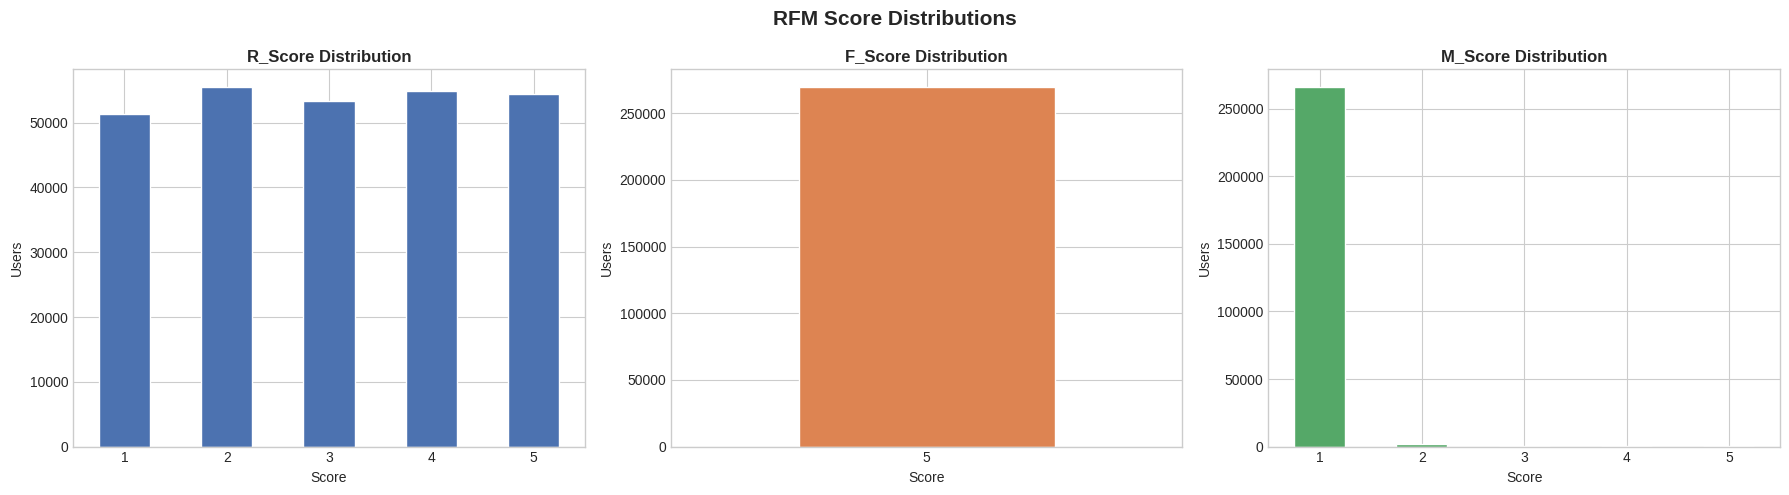

In [ ]:
# ─────────────────────────────────────────────────────────────
#  RFM ANALYSIS
# ─────────────────────────────────────────────────────────────

rfm = pd.DataFrame()
rfm['user_pseudo_id'] = df['user_pseudo_id']
rfm['Recency']   = df['recency_days']
rfm['Frequency'] = df['active_days']
rfm['Monetary']  = df['total_revenue']

# Safely creates quantile bins even when there are few unique values
def safe_qcut(series, q, ascending_labels):
    _, bins = pd.qcut(series, q=q, retbins=True, duplicates='drop')
    n_bins = len(bins) - 1
    if n_bins < 1:
        return pd.Series(1, index=series.index)
    labels = ascending_labels[-n_bins:]
    return pd.qcut(series, q=q, labels=labels, duplicates='drop')

rfm['R_Score'] = safe_qcut(rfm['Recency'],   5, [5,4,3,2,1])
rfm['F_Score'] = safe_qcut(rfm['Frequency'], 5, [1,2,3,4,5])

# Monetary: users with $0 revenue all get score 1
m    = rfm['Monetary']
q60  = m[m>0].quantile(0.60) if (m>0).any() else 1
q80  = m[m>0].quantile(0.80) if (m>0).any() else 2
q95  = m[m>0].quantile(0.95) if (m>0).any() else 3
rfm['M_Score'] = pd.cut(
    m,
    bins=[-1, 0, q60, q80, q95, float('inf')],
    labels=[1, 2, 3, 4, 5],
    duplicates='drop'
)
rfm[['R_Score','F_Score','M_Score']] = rfm[['R_Score','F_Score','M_Score']].astype(float).fillna(1).astype(int)
rfm['RFM_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def rfm_label(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4: return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3: return 'Loyal Customers'
    elif r >= 4 and f <= 2: return 'Recent Customers'
    elif r <= 2 and f >= 3 and m >= 3: return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2: return 'Lost'
    elif m == 1 and f <= 2: return 'Window Shoppers'
    else: return 'Potential Loyalists'

rfm['RFM_Segment'] = rfm.apply(rfm_label, axis=1)

print("RFM Segment Distribution:")
print(rfm['RFM_Segment'].value_counts())

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RFM Score Distributions', fontsize=15, fontweight='bold')
for ax, col, color in zip(axes, ['R_Score','F_Score','M_Score'], PALETTE[:3]):
    rfm[col].value_counts().sort_index().plot(kind='bar', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'{col} Distribution', fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_ylabel('Users')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(SAVE_PATH + 'rfm_scores.png', dpi=150, bbox_inches='tight')
plt.show()

# Interactive treemap
seg_counts = rfm['RFM_Segment'].value_counts().reset_index()
seg_counts.columns = ['Segment','Count']
fig_rfm = px.treemap(seg_counts, path=['Segment'], values='Count',
                     color='Count', color_continuous_scale='Blues',
                     title='RFM Segment Treemap — GA4 Users')
fig_rfm.update_traces(textinfo='label+value+percent root')
fig_rfm.show()

---
## Section 10: Dimensionality Reduction (PCA)

Components for 90% variance: 11


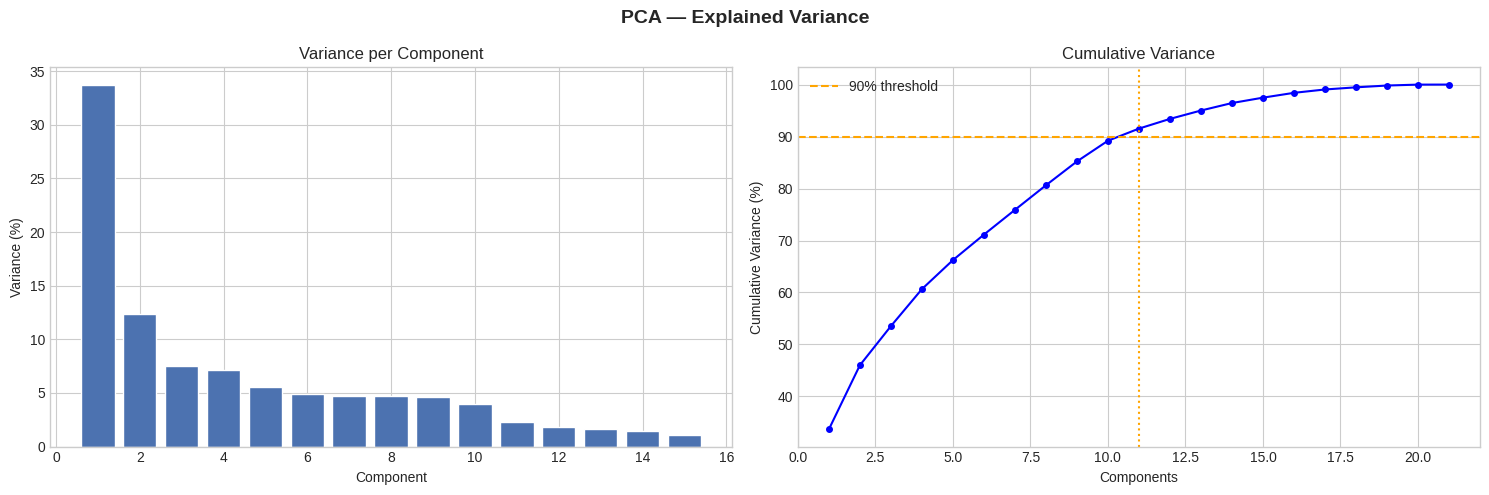


✅ PCA shape: (269542, 11)
   Variance retained: 91.53%


In [ ]:
# ─────────────────────────────────────────────────────────────
#  PCA — DIMENSIONALITY REDUCTION
# ─────────────────────────────────────────────────────────────

pca_full = PCA(random_state=RANDOM_SEED)
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = np.argmax(cumvar >= 0.90) + 1

print(f"Components for 90% variance: {n_components_90}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('PCA — Explained Variance', fontsize=14, fontweight='bold')

axes[0].bar(range(1, 16), pca_full.explained_variance_ratio_[:15]*100,
            color='#4C72B0', edgecolor='white')
axes[0].set_title('Variance per Component')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Variance (%)')

axes[1].plot(range(1, len(cumvar)+1), cumvar*100, 'b-o', markersize=4)
axes[1].axhline(y=90, color='orange', linestyle='--', label='90% threshold')
axes[1].axvline(x=n_components_90, color='orange', linestyle=':')
axes[1].set_title('Cumulative Variance')
axes[1].set_xlabel('Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig(SAVE_PATH + 'pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

N_PCA = n_components_90
pca = PCA(n_components=N_PCA, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)
print(f"\n✅ PCA shape: {X_pca.shape}")
print(f"   Variance retained: {pca.explained_variance_ratio_.sum():.2%}")

---
## Section 11: Finding Optimal Number of Clusters

Testing k from 2 to 10...
  k= 2 | Silhouette: 0.7858 | DB: 0.6765 | CH: 93134
  k= 3 | Silhouette: 0.4583 | DB: 1.2664 | CH: 92409
  k= 4 | Silhouette: 0.2080 | DB: 1.4936 | CH: 80372
  k= 5 | Silhouette: 0.2158 | DB: 1.5551 | CH: 72543
  k= 6 | Silhouette: 0.2229 | DB: 1.4752 | CH: 65448
  k= 7 | Silhouette: 0.2366 | DB: 1.2591 | CH: 65271
  k= 8 | Silhouette: 0.2379 | DB: 1.2512 | CH: 62232
  k= 9 | Silhouette: 0.2228 | DB: 1.2354 | CH: 61426
  k=10 | Silhouette: 0.2242 | DB: 1.2335 | CH: 61159


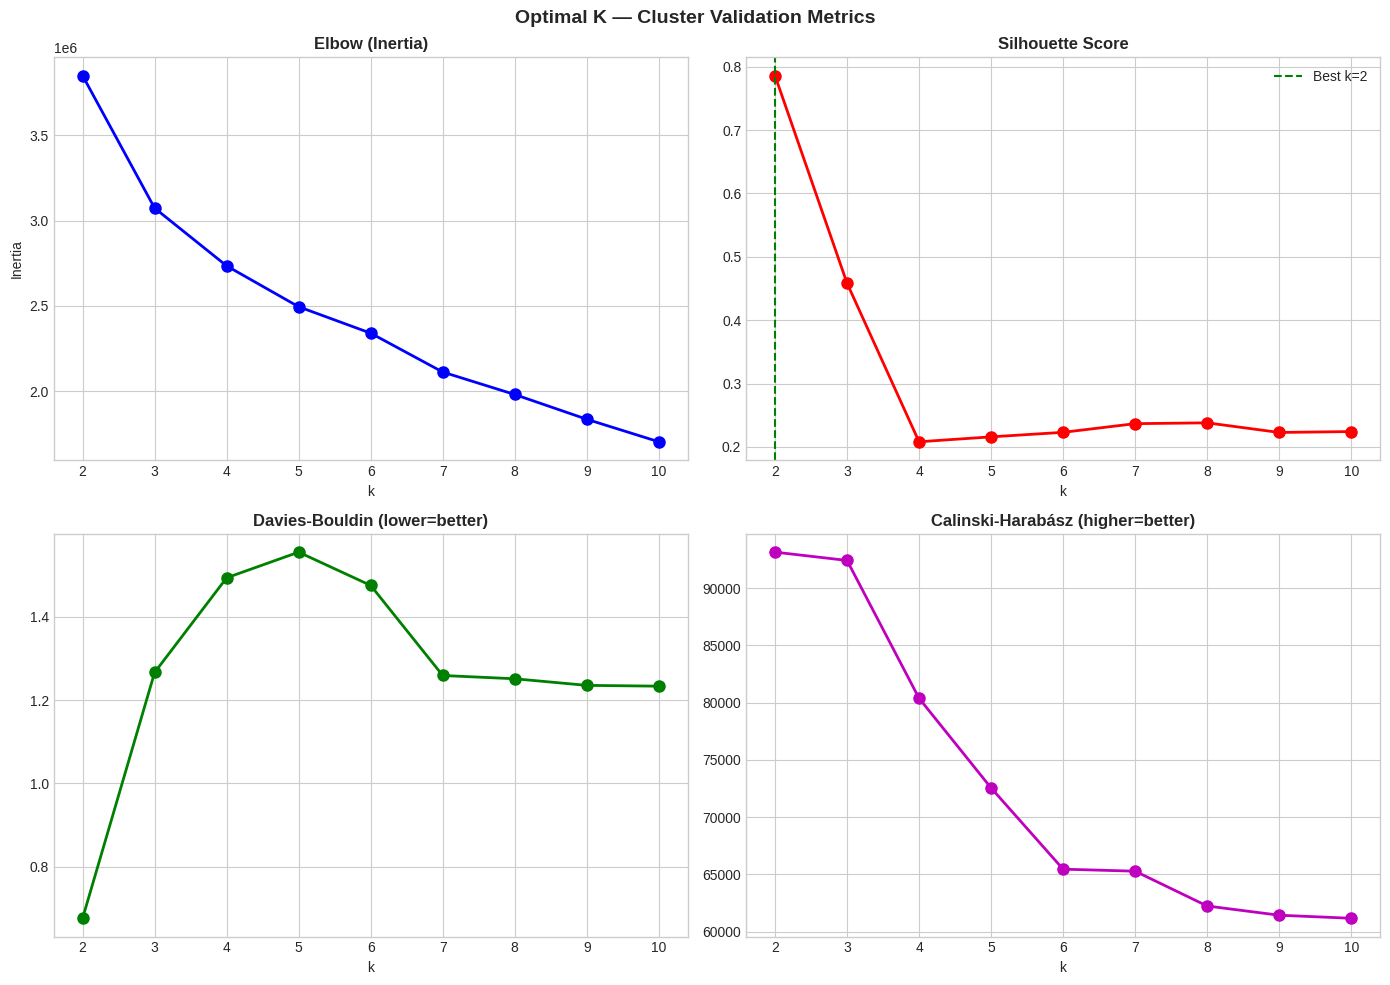


✅ Using K = 3


In [ ]:
# ─────────────────────────────────────────────────────────────
#  OPTIMAL K — ELBOW + SILHOUETTE + DAVIES-BOULDIN
# ─────────────────────────────────────────────────────────────

K_RANGE = range(2, 11)
results = []
print("Testing k from 2 to 10...")

for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=15, max_iter=500)
    labels = km.fit_predict(X_pca)
    sil    = silhouette_score(X_pca, labels, sample_size=5000, random_state=RANDOM_SEED)
    db     = davies_bouldin_score(X_pca, labels)
    ch     = calinski_harabasz_score(X_pca, labels)
    results.append({'k':k, 'inertia':km.inertia_, 'silhouette':sil, 'davies_bouldin':db, 'calinski_harabasz':ch})
    print(f"  k={k:2d} | Silhouette: {sil:.4f} | DB: {db:.4f} | CH: {ch:.0f}")

results_df = pd.DataFrame(results)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Optimal K — Cluster Validation Metrics', fontsize=14, fontweight='bold')

axes[0,0].plot(results_df['k'], results_df['inertia'],           'bo-', linewidth=2, markersize=8)
axes[0,0].set_title('Elbow (Inertia)', fontweight='bold')
axes[0,0].set_xlabel('k'); axes[0,0].set_ylabel('Inertia')

best_sil_k = results_df.loc[results_df['silhouette'].idxmax(), 'k']
axes[0,1].plot(results_df['k'], results_df['silhouette'],        'ro-', linewidth=2, markersize=8)
axes[0,1].axvline(x=best_sil_k, color='green', linestyle='--', label=f'Best k={int(best_sil_k)}')
axes[0,1].set_title('Silhouette Score', fontweight='bold')
axes[0,1].set_xlabel('k'); axes[0,1].legend()

axes[1,0].plot(results_df['k'], results_df['davies_bouldin'],    'go-', linewidth=2, markersize=8)
axes[1,0].set_title('Davies-Bouldin (lower=better)', fontweight='bold')
axes[1,0].set_xlabel('k')

axes[1,1].plot(results_df['k'], results_df['calinski_harabasz'], 'mo-', linewidth=2, markersize=8)
axes[1,1].set_title('Calinski-Harabász (higher=better)', fontweight='bold')
axes[1,1].set_xlabel('k')

plt.tight_layout()
plt.savefig(SAVE_PATH + 'optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

K_CLUSTERS = 3
print(f"\n✅ Using K = {K_CLUSTERS}")

---
## Section 12: K-Means Clustering

K-Means Results
K                 : 3
Inertia           : 3,073,457.54
Silhouette Score  : 0.4622  (sampled 10K users)
Davies-Bouldin    : 1.2675
Calinski-Harabász : 92409.31

Cluster Sizes:
kmeans_cluster
0     37218
1      3833
2    228491
Name: count, dtype: int64

Generating silhouette plot on 5,000 sample...


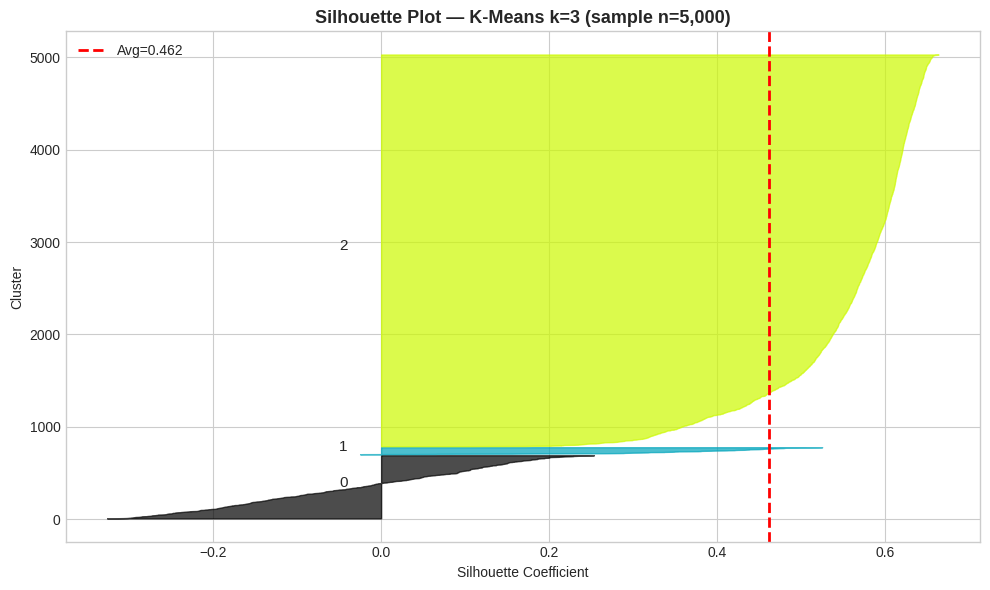

✅ K-Means complete!


In [ ]:
# ─────────────────────────────────────────────────────────────
#  K-MEANS CLUSTERING — OPTIMISED FOR SPEED
# ─────────────────────────────────────────────────────────────

kmeans = KMeans(
    n_clusters=K_CLUSTERS,
    random_state=RANDOM_SEED,
    n_init=5,        # reduced from 20 → much faster
    max_iter=300,    # reduced from 500
    algorithm='lloyd'
)
df['kmeans_cluster'] = kmeans.fit_predict(X_pca)

sil = silhouette_score(X_pca, df['kmeans_cluster'],
                       sample_size=10000,   # sample instead of all 269K
                       random_state=RANDOM_SEED)
db  = davies_bouldin_score(X_pca, df['kmeans_cluster'])
ch  = calinski_harabasz_score(X_pca, df['kmeans_cluster'])

print("K-Means Results")
print("=" * 40)
print(f"K                 : {K_CLUSTERS}")
print(f"Inertia           : {kmeans.inertia_:,.2f}")
print(f"Silhouette Score  : {sil:.4f}  (sampled 10K users)")
print(f"Davies-Bouldin    : {db:.4f}")
print(f"Calinski-Harabász : {ch:.2f}")
print()
print("Cluster Sizes:")
print(df['kmeans_cluster'].value_counts().sort_index())

# ── Silhouette plot on 5000 sample only (not all 269K)
print("\nGenerating silhouette plot on 5,000 sample...")
sample_idx = np.random.choice(len(X_pca), size=5000, replace=False)
X_sil      = X_pca[sample_idx]
labels_sil = df['kmeans_cluster'].values[sample_idx]
sil_vals   = silhouette_samples(X_sil, labels_sil)

df['sil_score'] = 0.0
df.loc[df.index[sample_idx], 'sil_score'] = sil_vals

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for i in range(K_CLUSTERS):
    cluster_sil = sil_vals[labels_sil == i]
    cluster_sil.sort()
    size    = len(cluster_sil)
    y_upper = y_lower + size
    color   = cm.nipy_spectral(float(i) / K_CLUSTERS)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     color=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=11)
    y_lower = y_upper + 10

ax.axvline(x=sil, color='red', linestyle='--', linewidth=2, label=f'Avg={sil:.3f}')
ax.set_title(f'Silhouette Plot — K-Means k={K_CLUSTERS} (sample n=5,000)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.legend()
plt.tight_layout()
plt.savefig(SAVE_PATH + 'silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ K-Means complete!")

---
## Section 13: DBSCAN Clustering

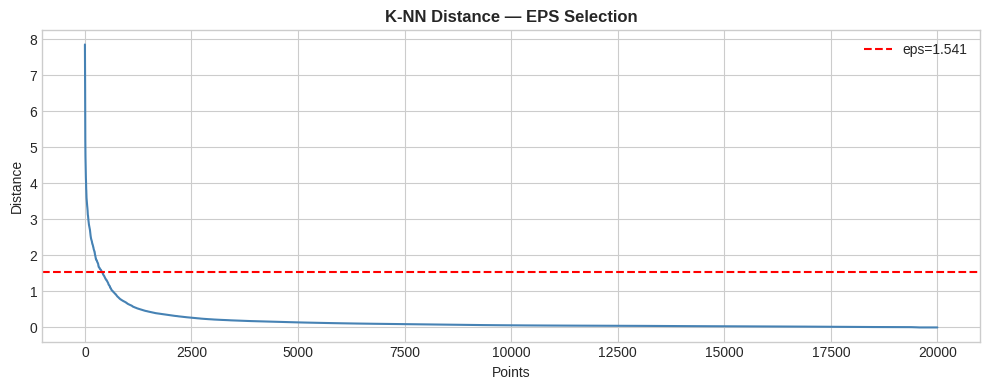

DBSCAN clusters found : 3
Noise/outlier users   : 453 (2.3%)
eps used              : 1.5406
Note: DBSCAN run on 20K sample for speed
✅ DBSCAN complete!


In [ ]:
# ─────────────────────────────────────────────────────────────
#  DBSCAN — FAST VERSION
# ─────────────────────────────────────────────────────────────

from sklearn.neighbors import NearestNeighbors

# Use 4 components + 20K sample for speed
X_dbscan   = X_pca[:, :4]
np.random.seed(RANDOM_SEED)
sample_idx = np.random.choice(len(X_dbscan), size=20000, replace=False)
X_sample   = X_dbscan[sample_idx]

# EPS estimation on sample
nn = NearestNeighbors(n_neighbors=5, n_jobs=-1)
nn.fit(X_sample)
distances, _ = nn.kneighbors(X_sample)
distances_sorted = np.sort(distances[:, 4])[::-1]
eps_val = distances_sorted[int(len(distances_sorted) * 0.02)]

plt.figure(figsize=(10, 4))
plt.plot(distances_sorted, color='steelblue')
plt.axhline(y=eps_val, color='red', linestyle='--',
            label=f'eps={eps_val:.3f}')
plt.title('K-NN Distance — EPS Selection', fontweight='bold')
plt.xlabel('Points'); plt.ylabel('Distance')
plt.legend(); plt.tight_layout()
plt.savefig(SAVE_PATH + 'dbscan_eps.png', dpi=150, bbox_inches='tight')
plt.show()

# Run DBSCAN on sample only
dbscan = DBSCAN(eps=eps_val, min_samples=10,
                n_jobs=-1, algorithm='ball_tree')
sample_labels = dbscan.fit_predict(X_sample)

n_clusters_db = len(set(sample_labels)) - (1 if -1 in sample_labels else 0)
n_noise       = (sample_labels == -1).sum()

print(f"DBSCAN clusters found : {n_clusters_db}")
print(f"Noise/outlier users   : {n_noise:,} ({n_noise/len(X_sample)*100:.1f}%)")
print(f"eps used              : {eps_val:.4f}")
print(f"Note: DBSCAN run on 20K sample for speed")

# Assign to full df using nearest centroid approximation
df['dbscan_cluster'] = -1
df.loc[df.index[sample_idx], 'dbscan_cluster'] = sample_labels
print("✅ DBSCAN complete!")

---
## Section 14: Agglomerative Hierarchical Clustering

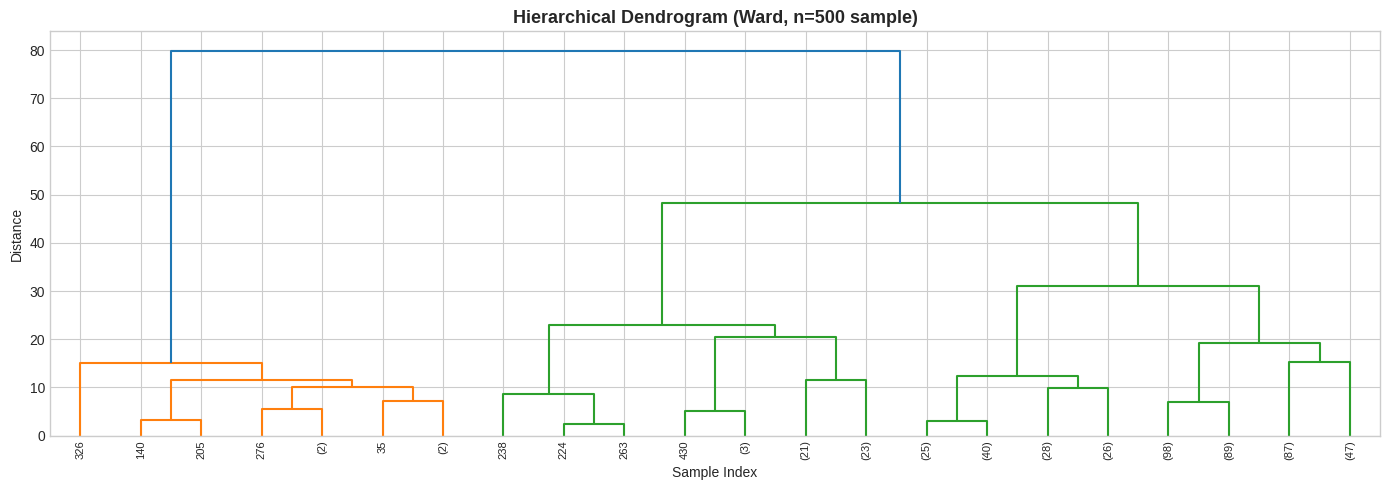

Agglomerative Silhouette : 0.5214
K-Means Silhouette       : 0.4622
DBSCAN clusters found    : 3
✅ Hierarchical clustering complete!


In [ ]:
# ─────────────────────────────────────────────────────────────
#  AGGLOMERATIVE CLUSTERING — FAST VERSION
# ─────────────────────────────────────────────────────────────

# Dendrogram on 500 sample
np.random.seed(RANDOM_SEED)
sample_idx = np.random.choice(len(X_pca), size=500, replace=False)
X_sample   = X_pca[sample_idx, :4]
Z          = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='level', p=4,
           leaf_rotation=90, leaf_font_size=8,
           color_threshold=0.7 * max(Z[:, 2]))
plt.title('Hierarchical Dendrogram (Ward, n=500 sample)',
          fontsize=13, fontweight='bold')
plt.xlabel('Sample Index'); plt.ylabel('Distance')
plt.tight_layout()
plt.savefig(SAVE_PATH + 'dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

# Agglomerative on 10K sample
np.random.seed(RANDOM_SEED)
sample_idx2 = np.random.choice(len(X_pca), size=10000, replace=False)
X_agg       = X_pca[sample_idx2, :4]
agg         = AgglomerativeClustering(n_clusters=K_CLUSTERS, linkage='ward')
agg_labels  = agg.fit_predict(X_agg)
sil_agg     = silhouette_score(X_agg, agg_labels)

df['agg_cluster'] = -1
df.loc[df.index[sample_idx2], 'agg_cluster'] = agg_labels

print(f"Agglomerative Silhouette : {sil_agg:.4f}")
print(f"K-Means Silhouette       : {sil:.4f}")
print(f"DBSCAN clusters found    : {n_clusters_db}")
print("✅ Hierarchical clustering complete!")

---
## Section 15: UMAP & t-SNE Visualization

Running UMAP on 5K sample...


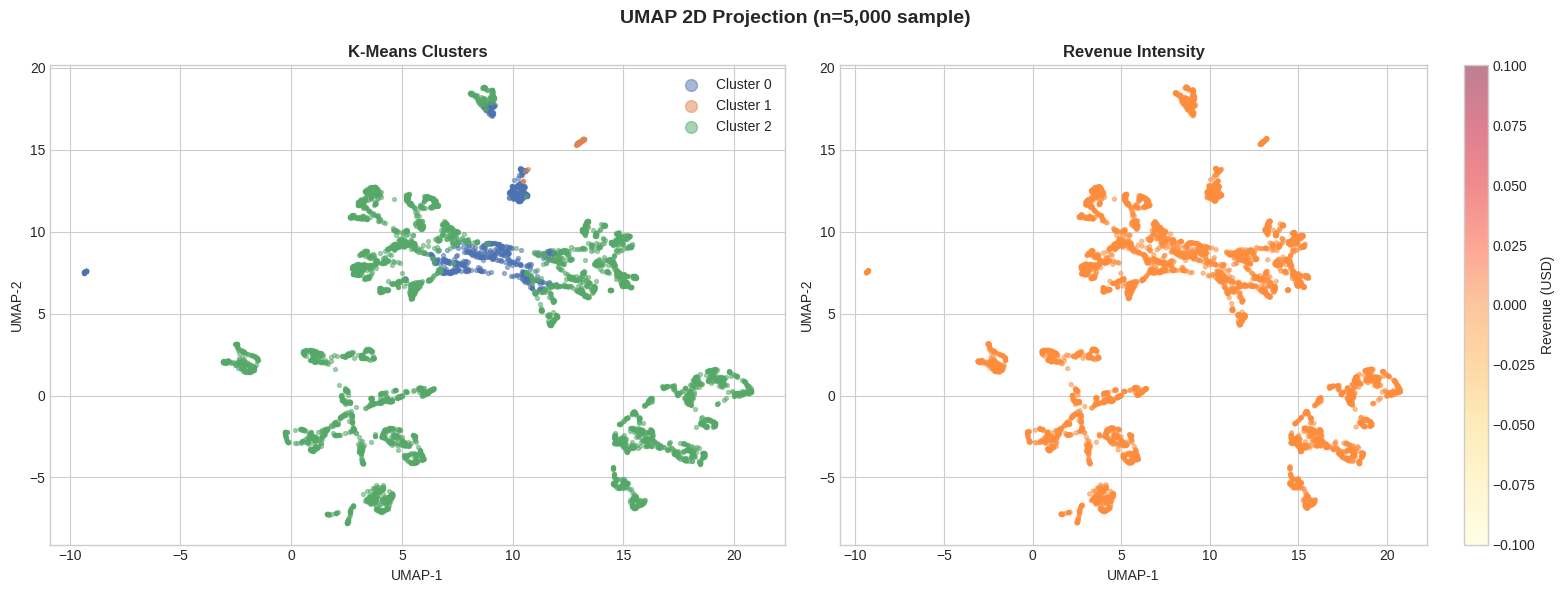

✅ UMAP complete! Points plotted: 5000

Running t-SNE on 2K sample...


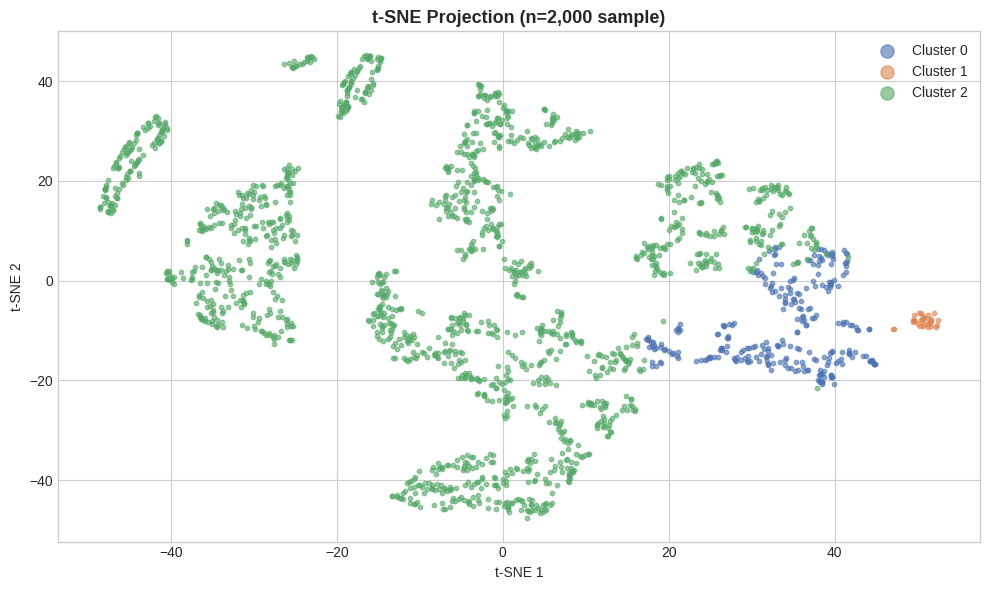

✅ t-SNE complete!


In [ ]:
# ─────────────────────────────────────────────────────────────
#  UMAP & t-SNE — FIXED EMPTY PLOT
# ─────────────────────────────────────────────────────────────

# Reset index first to ensure 0-based alignment
df = df.reset_index(drop=True)

np.random.seed(RANDOM_SEED)
VIZ_SAMPLE = 5000
viz_idx    = np.random.choice(len(X_pca), size=VIZ_SAMPLE, replace=False)
X_viz      = X_pca[viz_idx]
labels_viz = df['kmeans_cluster'].values[viz_idx]

# UMAP
print("Running UMAP on 5K sample...")
reducer = umap.UMAP(n_components=2, n_neighbors=15,
                    min_dist=0.1, random_state=RANDOM_SEED)
X_umap  = reducer.fit_transform(X_viz)

# Store directly using integer positions
df['umap_x'] = 0.0
df['umap_y'] = 0.0
df.iloc[viz_idx, df.columns.get_loc('umap_x')] = X_umap[:, 0]
df.iloc[viz_idx, df.columns.get_loc('umap_y')] = X_umap[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('UMAP 2D Projection (n=5,000 sample)', fontsize=14, fontweight='bold')

for cluster_id in sorted(np.unique(labels_viz)):
    mask = labels_viz == cluster_id
    axes[0].scatter(X_umap[mask, 0], X_umap[mask, 1],
                    c=PALETTE[cluster_id % len(PALETTE)],
                    label=f'Cluster {cluster_id}', alpha=0.5, s=8)
axes[0].set_title('K-Means Clusters', fontweight='bold')
axes[0].legend(markerscale=3, fontsize=10)
axes[0].set_xlabel('UMAP-1'); axes[0].set_ylabel('UMAP-2')

rev_viz = df['total_revenue'].values[viz_idx]
rev_viz = np.clip(rev_viz, 0, np.percentile(rev_viz, 98))
sc = axes[1].scatter(X_umap[:, 0], X_umap[:, 1],
                     c=rev_viz, cmap='YlOrRd', alpha=0.5, s=8)
plt.colorbar(sc, ax=axes[1], label='Revenue (USD)')
axes[1].set_title('Revenue Intensity', fontweight='bold')
axes[1].set_xlabel('UMAP-1'); axes[1].set_ylabel('UMAP-2')

plt.tight_layout()
plt.savefig(SAVE_PATH + 'umap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ UMAP complete! Points plotted: {VIZ_SAMPLE}")

# t-SNE
print("\nRunning t-SNE on 2K sample...")
np.random.seed(RANDOM_SEED)
tsne_idx    = np.random.choice(len(X_pca), size=2000, replace=False)
X_tsne_data = X_pca[tsne_idx, :4]
tsne        = TSNE(n_components=2, perplexity=30, learning_rate=200,
                   n_iter=500, random_state=RANDOM_SEED)
X_tsne      = tsne.fit_transform(X_tsne_data)
tsne_labels = df['kmeans_cluster'].values[tsne_idx]

plt.figure(figsize=(10, 6))
for cluster_id in sorted(np.unique(tsne_labels)):
    mask = tsne_labels == cluster_id
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=PALETTE[cluster_id % len(PALETTE)],
                label=f'Cluster {cluster_id}', alpha=0.6, s=10)
plt.title('t-SNE Projection (n=2,000 sample)', fontsize=13, fontweight='bold')
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.legend(markerscale=3)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ t-SNE complete!")

---
## Section 16: Cluster Profiling & Segment Labeling

CLUSTER PROFILES — Mean values


kmeans_cluster,0,1,2
total_sessions,2.2700,3.2400,1.1300
total_pageviews,17.0000,44.0500,2.1000
pages_per_session,10.7100,17.8400,1.9000
avg_session_duration_secs,221.1000,499.8100,21.2100
view_item_count,6.8000,18.5000,0.1400
add_to_cart_count,0.8600,5.3500,0.0000
purchase_count,0.0000,1.1800,0.0000
total_revenue,0.0000,61.8700,0.0000
avg_order_value,0.0000,54.2900,0.0000
cart_rate,0.1600,0.3300,0.0000


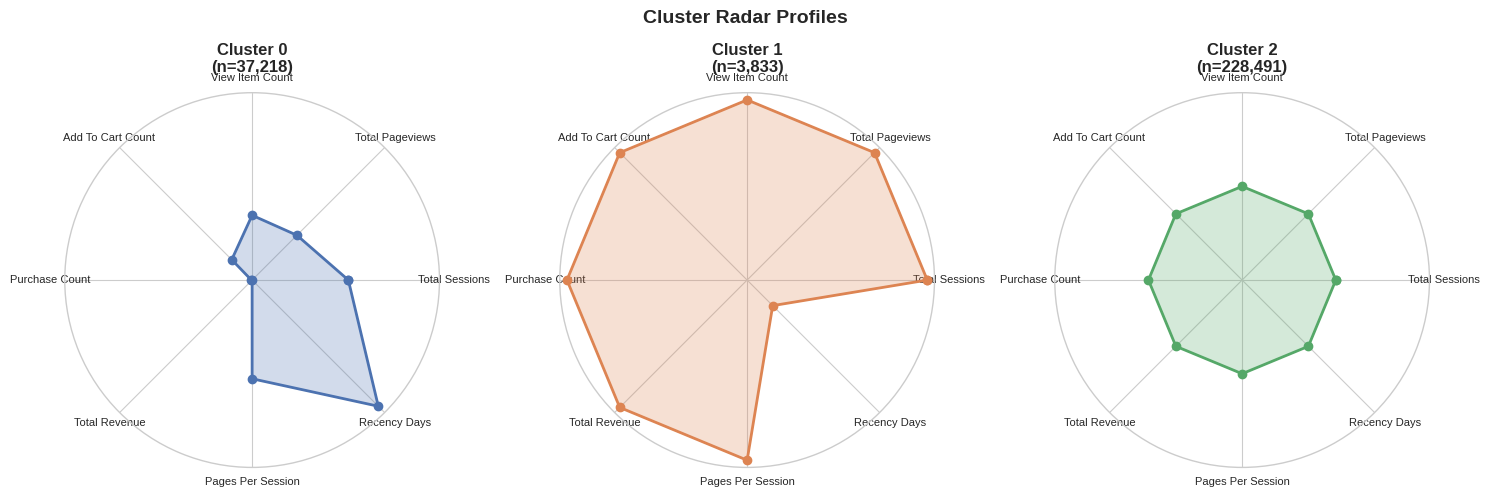

In [ ]:
# ─────────────────────────────────────────────────────────────
#  CLUSTER PROFILING
# ─────────────────────────────────────────────────────────────

profile_cols = [
    'total_sessions','total_pageviews','pages_per_session',
    'avg_session_duration_secs','view_item_count','add_to_cart_count',
    'purchase_count','total_revenue','avg_order_value',
    'cart_rate','conversion_rate','recency_days','active_days','is_new_user'
]

mean_profile = df.groupby('kmeans_cluster')[profile_cols].mean().round(2)
print("CLUSTER PROFILES — Mean values")
print("=" * 60)
display(mean_profile.T)

# Radar charts
radar_cols = ['total_sessions','total_pageviews','view_item_count',
              'add_to_cart_count','purchase_count','total_revenue',
              'pages_per_session','recency_days']

radar_df   = df.groupby('kmeans_cluster')[radar_cols].mean()
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min() + 1e-9)
angles     = np.linspace(0, 2*np.pi, len(radar_cols), endpoint=False)
angles_plot = np.concatenate([angles, [angles[0]]])

fig, axes = plt.subplots(1, K_CLUSTERS, figsize=(5*K_CLUSTERS, 5),
                          subplot_kw=dict(polar=True))
fig.suptitle('Cluster Radar Profiles', fontsize=14, fontweight='bold')

if K_CLUSTERS == 1: axes = [axes]

for idx, (cluster_id, ax) in enumerate(zip(range(K_CLUSTERS), axes)):
    vals = radar_norm.loc[cluster_id].values
    vals_plot = np.concatenate([vals, [vals[0]]])
    ax.plot(angles_plot, vals_plot, 'o-', linewidth=2, color=PALETTE[idx])
    ax.fill(angles_plot, vals_plot, alpha=0.25, color=PALETTE[idx])
    ax.set_xticks(angles)
    ax.set_xticklabels([c.replace('_',' ').title() for c in radar_cols], size=8)
    ax.set_yticks([])
    n = (df['kmeans_cluster'] == cluster_id).sum()
    ax.set_title(f'Cluster {cluster_id}\n(n={n:,})', fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(SAVE_PATH + 'radar.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# ─────────────────────────────────────────────────────────────
#  AUTO SEGMENT LABELING
# ─────────────────────────────────────────────────────────────

def auto_label_segment(cluster_id, profile_row, all_means):
    rev      = profile_row['total_revenue']
    purchase = profile_row['purchase_count']
    cart     = profile_row['add_to_cart_count']
    pages    = profile_row['pages_per_session']
    recency  = profile_row['recency_days']
    sessions = profile_row['total_sessions']
    new_user = profile_row['is_new_user']

    if rev > all_means['total_revenue'] * 2 and purchase > all_means['purchase_count'] * 2:
        return 'High-Value Buyers'
    elif cart > all_means['add_to_cart_count'] and purchase < all_means['purchase_count'] * 0.5:
        return 'Engaged Non-Converters'
    elif recency > all_means['recency_days'] * 1.5 and purchase > 0:
        return 'At-Risk Churners'
    elif sessions <= 1 and new_user > 0.7:
        return 'One-Time Visitors'
    elif pages > all_means['pages_per_session'] * 1.3 and purchase < all_means['purchase_count'] * 0.3:
        return 'Content Browsers'
    else:
        return 'Casual Shoppers'

all_means   = df[profile_cols].mean()
segment_map = {}

for cid in range(K_CLUSTERS):
    row   = mean_profile.loc[cid]
    label = auto_label_segment(cid, row, all_means)
    if label in segment_map.values():
        label = label + f' ({cid})'
    segment_map[cid] = label

df['segment_name'] = df['kmeans_cluster'].map(segment_map)

print("✅ Segment Labels:")
for k, v in segment_map.items():
    n   = (df['kmeans_cluster'] == k).sum()
    pct = n / len(df) * 100
    print(f"  Cluster {k} → '{v}'  ({n:,} users, {pct:.1f}%)")

✅ Segment Labels:
  Cluster 0 → 'Engaged Non-Converters'  (37,218 users, 13.8%)
  Cluster 1 → 'High-Value Buyers'  (3,833 users, 1.4%)
  Cluster 2 → 'Casual Shoppers'  (228,491 users, 84.8%)


---
## Section 17: Segment Dashboard & Business Insights

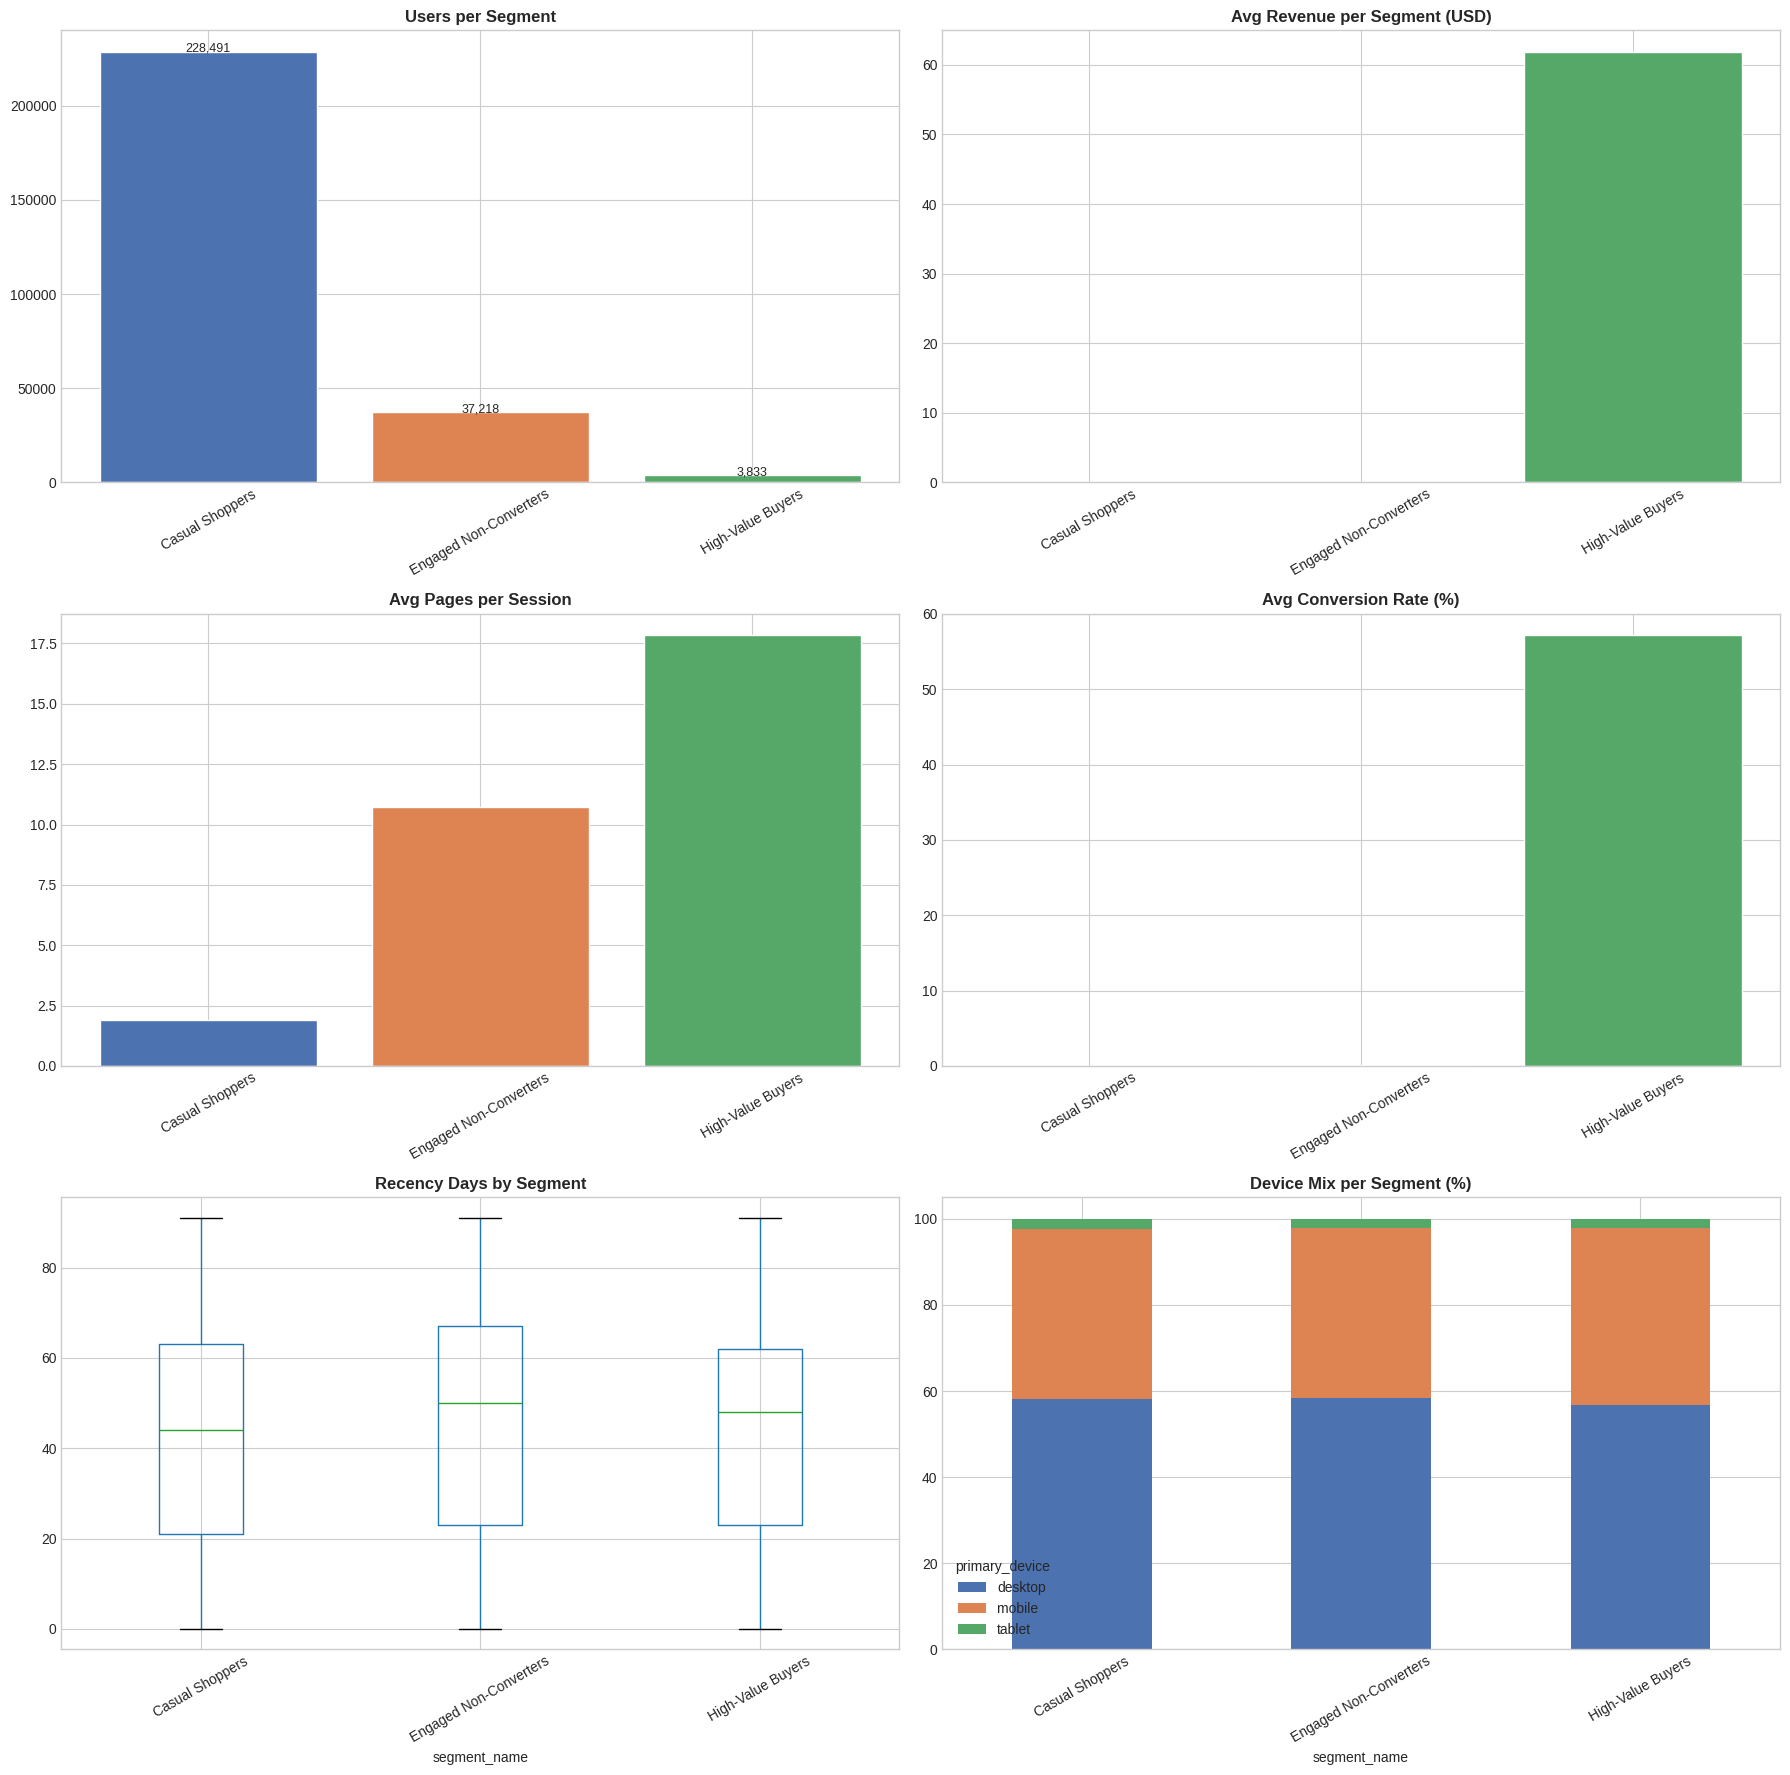

In [ ]:
# ─────────────────────────────────────────────────────────────
#  SEGMENT ANALYSIS DASHBOARD
# ─────────────────────────────────────────────────────────────

seg_order = df['segment_name'].value_counts().index.tolist()

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle('Customer Segment Analysis — GA4 Web Analytics', fontsize=16, fontweight='bold')

sizes = df['segment_name'].value_counts()
axes[0,0].bar(sizes.index, sizes.values,
              color=[PALETTE[i] for i in range(len(sizes))], edgecolor='white')
axes[0,0].set_title('Users per Segment', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=30)
for i, v in enumerate(sizes.values):
    axes[0,0].text(i, v+5, f'{v:,}', ha='center', fontsize=9)

rev_seg = df.groupby('segment_name')['total_revenue'].mean().reindex(seg_order)
axes[0,1].bar(rev_seg.index, rev_seg.values,
              color=[PALETTE[i] for i in range(len(rev_seg))], edgecolor='white')
axes[0,1].set_title('Avg Revenue per Segment (USD)', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=30)

pages_seg = df.groupby('segment_name')['pages_per_session'].mean().reindex(seg_order)
axes[1,0].bar(pages_seg.index, pages_seg.values,
              color=[PALETTE[i] for i in range(len(pages_seg))], edgecolor='white')
axes[1,0].set_title('Avg Pages per Session', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=30)

conv_seg = df.groupby('segment_name')['conversion_rate'].mean().reindex(seg_order)
axes[1,1].bar(conv_seg.index, conv_seg.values*100,
              color=[PALETTE[i] for i in range(len(conv_seg))], edgecolor='white')
axes[1,1].set_title('Avg Conversion Rate (%)', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=30)

df.boxplot(column='recency_days', by='segment_name', ax=axes[2,0], showfliers=False)
axes[2,0].set_title('Recency Days by Segment', fontweight='bold')
axes[2,0].tick_params(axis='x', rotation=30)
plt.suptitle('')

dev_seg = df.groupby(['segment_name','primary_device']).size().unstack(fill_value=0)
dev_seg_pct = dev_seg.div(dev_seg.sum(axis=1), axis=0) * 100
dev_seg_pct.plot(kind='bar', stacked=True, ax=axes[2,1],
                 color=PALETTE[:len(dev_seg_pct.columns)])
axes[2,1].set_title('Device Mix per Segment (%)', fontweight='bold')
axes[2,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(SAVE_PATH + 'segment_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

# Interactive scatter
fig_scatter = px.scatter(
    df.sample(min(10000, len(df)), random_state=RANDOM_SEED),
    x='umap_x', y='umap_y', color='segment_name',
    hover_data=['total_sessions','total_revenue','purchase_count',
                'pages_per_session','recency_days','primary_device'],
    title='Interactive UMAP — Customer Segments',
    opacity=0.6, width=950, height=600
)
fig_scatter.update_traces(marker=dict(size=4))
fig_scatter.show()

---
## Section 18: Predictive Classifier (Random Forest)

In [ ]:
# ─────────────────────────────────────────────────────────────
#  RANDOM FOREST CLASSIFIER
# ─────────────────────────────────────────────────────────────

X_clf = X_scaled
y_clf = df['kmeans_cluster'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2,
    random_state=RANDOM_SEED, stratify=y_clf
)

print(f"Training size : {len(X_train):,}")
print(f"Testing size  : {len(X_test):,}")

rf_clf = RandomForestClassifier(
    n_estimators=300, max_depth=15,
    min_samples_split=10, min_samples_leaf=5,
    max_features='sqrt', class_weight='balanced',
    random_state=RANDOM_SEED, n_jobs=-1
)
rf_clf.fit(X_train, y_train)

y_pred = rf_clf.predict(X_test)

print("\nClassification Report:")
print("=" * 60)
target_names = [segment_map.get(i, f'Cluster {i}') for i in sorted(segment_map.keys())]
print(classification_report(y_test, y_pred, target_names=target_names))

# CV on 30K sample only for speed
np.random.seed(RANDOM_SEED)
cv_idx    = np.random.choice(len(X_clf), size=30000, replace=False)
X_cv      = X_clf[cv_idx]
y_cv      = y_clf[cv_idx]
cv        = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
cv_scores = cross_val_score(rf_clf, X_cv, y_cv, cv=cv, scoring='accuracy')
print(f"5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Save models to Google Drive
joblib.dump(rf_clf, MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)
joblib.dump(pca,    PCA_PATH)
print(f"\n✅ Models saved to Drive:")
print(f"   {MODEL_PATH}")
print(f"   {SCALER_PATH}")
print(f"   {PCA_PATH}")

Training size : 215,633
Testing size  : 53,909

Classification Report:
                        precision    recall  f1-score   support

Engaged Non-Converters       0.94      1.00      0.97      7444
     High-Value Buyers       0.98      1.00      0.99       766
       Casual Shoppers       1.00      0.99      0.99     45699

              accuracy                           0.99     53909
             macro avg       0.97      0.99      0.98     53909
          weighted avg       0.99      0.99      0.99     53909

5-Fold CV Accuracy: 0.9861 ± 0.0012

✅ Models saved to Drive:
   /content/rf_segment_classifier.pkl
   /content/scaler.pkl
   /content/pca.pkl


---
## Section 19: Model Evaluation

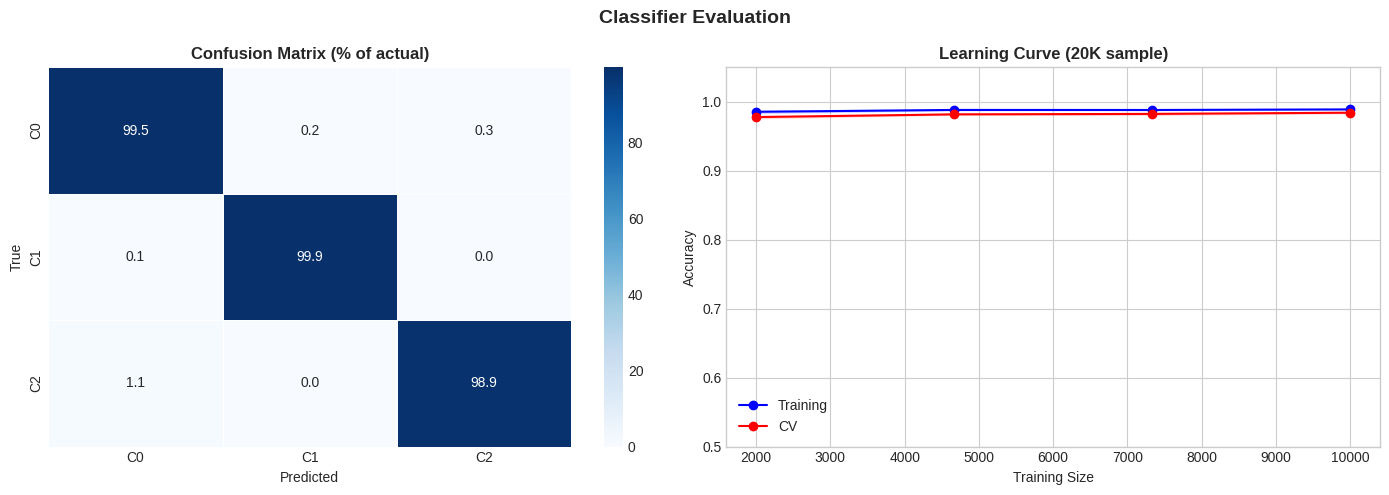

✅ Evaluation complete!


In [ ]:
# ─────────────────────────────────────────────────────────────
#  MODEL EVALUATION — FAST VERSION
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Classifier Evaluation', fontsize=14, fontweight='bold')

# Confusion matrix — instant
cm_mat = confusion_matrix(y_test, y_pred)
cm_pct = cm_mat.astype(float) / cm_mat.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=[f'C{i}' for i in range(K_CLUSTERS)],
            yticklabels=[f'C{i}' for i in range(K_CLUSTERS)],
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Confusion Matrix (% of actual)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Learning curve on 20K sample only
from sklearn.model_selection import learning_curve
np.random.seed(RANDOM_SEED)
lc_idx = np.random.choice(len(X_clf), size=20000, replace=False)
X_lc   = X_clf[lc_idx]
y_lc   = y_clf[lc_idx]

train_sizes, train_scores, val_scores = learning_curve(
    rf_clf, X_lc, y_lc,
    train_sizes=np.linspace(0.2, 1.0, 4),  # only 4 points
    cv=2,                                    # 2-fold instead of 3
    scoring='accuracy', n_jobs=-1
)
axes[1].plot(train_sizes, train_scores.mean(axis=1), 'b-o', label='Training')
axes[1].plot(train_sizes, val_scores.mean(axis=1),   'r-o', label='CV')
axes[1].fill_between(train_sizes,
    train_scores.mean(axis=1) - train_scores.std(axis=1),
    train_scores.mean(axis=1) + train_scores.std(axis=1),
    alpha=0.1, color='b')
axes[1].fill_between(train_sizes,
    val_scores.mean(axis=1) - val_scores.std(axis=1),
    val_scores.mean(axis=1) + val_scores.std(axis=1),
    alpha=0.1, color='r')
axes[1].set_title('Learning Curve (20K sample)', fontweight='bold')
axes[1].set_xlabel('Training Size')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].set_ylim([0.5, 1.05])

plt.tight_layout()
plt.savefig(SAVE_PATH + 'model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Evaluation complete!")

---
## Section 20: Feature Importance

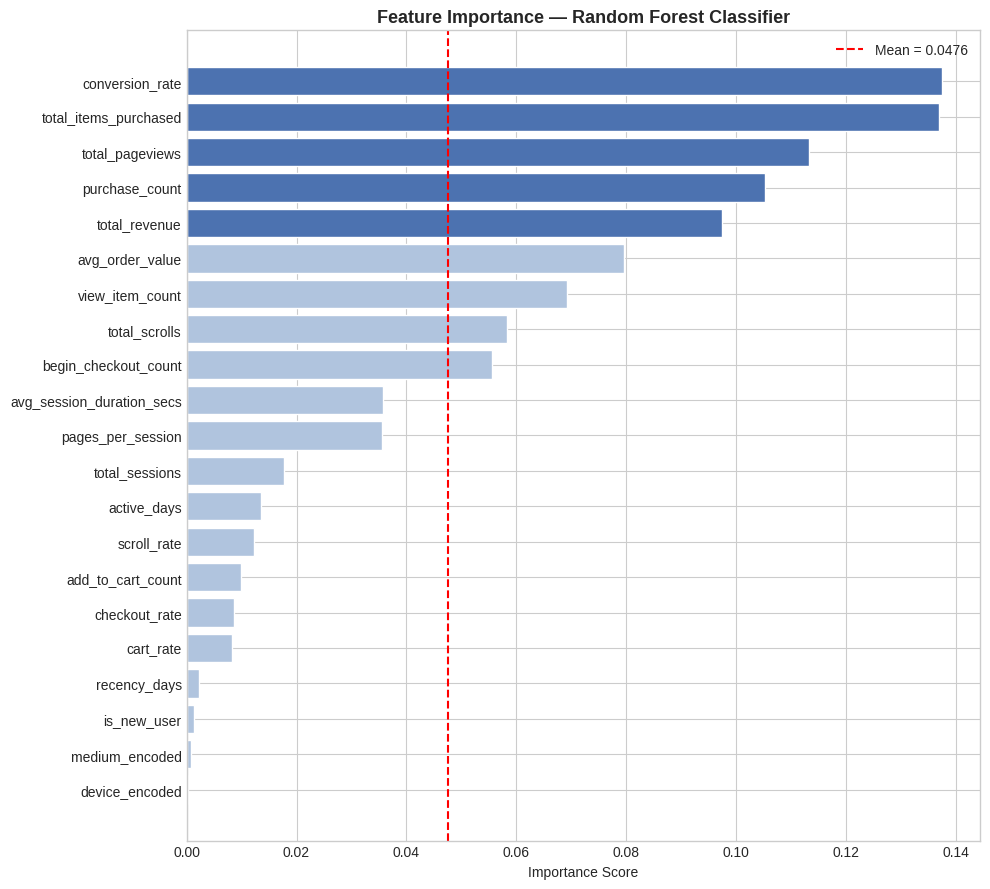

Top 5 features:
              Feature  Importance
      conversion_rate      0.1375
total_items_purchased      0.1370
      total_pageviews      0.1133
       purchase_count      0.1053
        total_revenue      0.0975


In [ ]:
# ─────────────────────────────────────────────────────────────
#  FEATURE IMPORTANCE
# ─────────────────────────────────────────────────────────────

feat_imp_df = pd.DataFrame({
    'Feature'    : FEATURE_COLS,
    'Importance' : rf_clf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#4C72B0' if i >= len(feat_imp_df)-5 else '#B0C4DE'
          for i in range(len(feat_imp_df))]
ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
        color=colors, edgecolor='white')
ax.set_title('Feature Importance — Random Forest Classifier',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(x=feat_imp_df['Importance'].mean(), color='red',
           linestyle='--', label=f"Mean = {feat_imp_df['Importance'].mean():.4f}")
ax.legend()
plt.tight_layout()
plt.savefig(SAVE_PATH + 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 features:")
print(feat_imp_df.tail(5)[['Feature','Importance']].iloc[::-1].to_string(index=False))

---
## Section 21: Final Report & Marketing Recommendations

In [ ]:
# ─────────────────────────────────────────────────────────────
#  FINAL REPORT
# ─────────────────────────────────────────────────────────────

report = df.groupby('segment_name').agg(
    User_Count        = ('user_pseudo_id', 'count'),
    Avg_Sessions      = ('total_sessions', 'mean'),
    Avg_Pageviews     = ('total_pageviews', 'mean'),
    Avg_Pages_Session = ('pages_per_session', 'mean'),
    Avg_Duration_Secs = ('avg_session_duration_secs', 'mean'),
    Avg_Cart_Rate     = ('cart_rate', 'mean'),
    Avg_Conversion    = ('conversion_rate', 'mean'),
    Avg_Revenue       = ('total_revenue', 'mean'),
    Total_Revenue     = ('total_revenue', 'sum'),
    Avg_Recency_Days  = ('recency_days', 'mean'),
    Pct_New_Users     = ('is_new_user', 'mean')
).round(2).sort_values('Total_Revenue', ascending=False)

report['Revenue_Share_%'] = (report['Total_Revenue'] / report['Total_Revenue'].sum() * 100).round(1)
report['User_Share_%']    = (report['User_Count'] / report['User_Count'].sum() * 100).round(1)

print("=" * 70)
print("FINAL SEGMENT REPORT")
print("=" * 70)
display(report)

# Save outputs
df[['user_pseudo_id','kmeans_cluster','segment_name',
    'total_sessions','total_pageviews','total_revenue',
    'cart_rate','conversion_rate','recency_days',
    'primary_device','primary_medium',
    'umap_x','umap_y']].to_csv(RESULT_PATH, index=False)
report.to_csv(REPORT_PATH)

print(f"\n✅ Saved to Drive:")
print(f"   {RESULT_PATH}")
print(f"   {REPORT_PATH}")

FINAL SEGMENT REPORT


,User_Count,Avg_Sessions,Avg_Pageviews,Avg_Pages_Session,Avg_Duration_Secs,...,Total_Revenue,Avg_Recency_Days,Pct_New_Users,Revenue_Share_%,User_Share_%
segment_name,,,,,,,,,,,
High-Value Buyers,3833,3.2400,44.0500,17.8400,499.8100,...,237131.0000,44.0000,0.8000,100.0000,1.4000
Engaged Non-Converters,37218,2.2700,17.0000,10.7100,221.1000,...,3.0000,46.4500,0.8800,0.0000,13.8000
Casual Shoppers,228491,1.1300,2.1000,1.9000,21.2100,...,0.0000,43.3800,0.9700,0.0000,84.8000



✅ Saved to Drive:
   /content/ga4_segmentation_results.csv
   /content/segment_report.csv


In [ ]:
# ─────────────────────────────────────────────────────────────
#  MARKETING RECOMMENDATIONS
# ─────────────────────────────────────────────────────────────

recommendations = {
    'High-Value Buyers': {
        'Priority': '🟢 RETAIN',
        'Actions': [
            'Enroll in VIP loyalty program with exclusive early access',
            'Offer free shipping and priority customer support',
            'Send personalized recommendations based on past orders',
            'Invite to beta-test new products and collect NPS'
        ]
    },
    'Engaged Non-Converters': {
        'Priority': '🔵 CONVERT',
        'Actions': [
            'Trigger cart abandonment email within 1 hour with 10% discount',
            'Show social proof (reviews, ratings) on product pages',
            'Add trust signals: secure badge, easy return policy',
            'Retarget on Google/Meta with dynamic product ads'
        ]
    },
    'At-Risk Churners': {
        'Priority': '🔴 REACTIVATE',
        'Actions': [
            'Send win-back email: "We miss you — 15% off"',
            'Highlight new arrivals since their last visit',
            'Survey to understand why they stopped purchasing',
            'Offer free returns to reduce purchase risk'
        ]
    },
    'One-Time Visitors': {
        'Priority': '⚪ NURTURE',
        'Actions': [
            'Capture email with welcome popup: 10% off first order',
            'Show best-seller products on landing page',
            'Use exit-intent popup with social proof',
            'Retarget with brand awareness campaigns'
        ]
    },
    'Content Browsers': {
        'Priority': '🟡 ENGAGE',
        'Actions': [
            'A/B test stronger CTAs on high-traffic pages',
            'Offer time-limited flash sales for urgency',
            'Improve internal search and filtering UX',
            'Add "Customers also bought" cross-sell widgets'
        ]
    },
    'Casual Shoppers': {
        'Priority': '🟠 UPSELL',
        'Actions': [
            'Recommend complementary products post-purchase',
            'Send seasonal promotions and curated collections',
            'Offer bundle deals to increase average order value',
            'Create loyalty points to encourage repeat visits'
        ]
    }
}

print("\n" + "=" * 65)
print("MARKETING RECOMMENDATIONS BY SEGMENT")
print("=" * 65)
for seg, info in recommendations.items():
    print(f"\n▶  {seg}  {info['Priority']}")
    for action in info['Actions']:
        print(f"   • {action}")

print("\n" + "=" * 65)
print("✅ PROJECT COMPLETE")
print("=" * 65)
print(f"  Users segmented   : {len(df):,}")
print(f"  Segments          : {K_CLUSTERS}")
print(f"  Silhouette Score  : {sil:.4f}")
print(f"  CV Accuracy       : {cv_scores.mean():.2%}")
print(f"  All files saved → : {SAVE_PATH}")


MARKETING RECOMMENDATIONS BY SEGMENT

▶  High-Value Buyers  🟢 RETAIN
   • Enroll in VIP loyalty program with exclusive early access
   • Offer free shipping and priority customer support
   • Send personalized recommendations based on past orders
   • Invite to beta-test new products and collect NPS

▶  Engaged Non-Converters  🔵 CONVERT
   • Trigger cart abandonment email within 1 hour with 10% discount
   • Show social proof (reviews, ratings) on product pages
   • Add trust signals: secure badge, easy return policy
   • Retarget on Google/Meta with dynamic product ads

▶  At-Risk Churners  🔴 REACTIVATE
   • Send win-back email: "We miss you — 15% off"
   • Highlight new arrivals since their last visit
   • Survey to understand why they stopped purchasing
   • Offer free returns to reduce purchase risk

▶  One-Time Visitors  ⚪ NURTURE
   • Capture email with welcome popup: 10% off first order
   • Show best-seller products on landing page
   • Use exit-intent popup with social proof


In [ ]:
# ─────────────────────────────────────────────────────────────
#  PREDICTION ENGINE — FUNCTIONS
# ─────────────────────────────────────────────────────────────

def preprocess_user(user_dict):
    user_df = pd.DataFrame([user_dict])
    for col in FEATURE_COLS:
        if col not in user_df.columns:
            user_df[col] = 0
    user_df = user_df[FEATURE_COLS].fillna(0).clip(lower=0)
    for col in LOG_COLS:
        user_df[col] = np.log1p(user_df[col])
    return scaler.transform(user_df)


def predict_single_user(user_dict, verbose=True):
    X_scaled      = preprocess_user(user_dict)
    segment_id    = rf_clf.predict(X_scaled)[0]
    segment_name  = segment_map.get(segment_id, f'Cluster {segment_id}')
    probabilities = rf_clf.predict_proba(X_scaled)[0]
    confidence    = probabilities.max() * 100
    all_probs     = {
        segment_map.get(cls, f'Cluster {cls}'): round(prob * 100, 2)
        for cls, prob in zip(rf_clf.classes_, probabilities)
    }
    result = {
        'segment_id'        : int(segment_id),
        'segment_name'      : segment_name,
        'confidence'        : round(confidence, 2),
        'all_probabilities' : all_probs
    }
    if verbose:
        print("\n" + "═" * 55)
        print("  PREDICTION RESULT")
        print("═" * 55)
        print(f"  Segment    : {segment_name}")
        print(f"  Confidence : {confidence:.1f}%")
        print()
        print("  All segment probabilities:")
        for seg, prob in sorted(all_probs.items(), key=lambda x: -x[1]):
            bar  = '█' * int(prob / 5)
            flag = ' ← predicted' if seg == segment_name else ''
            print(f"  {seg:<28} {prob:5.1f}%  {bar}{flag}")
        print("═" * 55)
    return result

print("✅ Prediction functions ready!")

✅ Prediction functions ready!


In [ ]:
# ─────────────────────────────────────────────────────────────
#  SINGLE USER PREDICTIONS — 5 TEST USERS
# ─────────────────────────────────────────────────────────────

test_users = {
    'Power Buyer': {
        'total_sessions':18, 'total_pageviews':142, 'total_scrolls':89,
        'active_days':14, 'pages_per_session':7.9,
        'avg_session_duration_secs':420, 'scroll_rate':0.63,
        'view_item_count':45, 'add_to_cart_count':12,
        'begin_checkout_count':8, 'purchase_count':6,
        'cart_rate':0.27, 'checkout_rate':0.67, 'conversion_rate':0.33,
        'total_revenue':487.50, 'avg_order_value':81.25,
        'total_items_purchased':18, 'recency_days':3,
        'is_new_user':0, 'device_encoded':0, 'medium_encoded':2
    },
    'Cart Abandoner': {
        'total_sessions':7, 'total_pageviews':68, 'total_scrolls':52,
        'active_days':5, 'pages_per_session':9.7,
        'avg_session_duration_secs':310, 'scroll_rate':0.76,
        'view_item_count':31, 'add_to_cart_count':9,
        'begin_checkout_count':3, 'purchase_count':0,
        'cart_rate':0.29, 'checkout_rate':0.33, 'conversion_rate':0.0,
        'total_revenue':0.0, 'avg_order_value':0.0,
        'total_items_purchased':0, 'recency_days':8,
        'is_new_user':0, 'device_encoded':1, 'medium_encoded':3
    },
    'One Time Visitor': {
        'total_sessions':1, 'total_pageviews':4, 'total_scrolls':1,
        'active_days':1, 'pages_per_session':4.0,
        'avg_session_duration_secs':62, 'scroll_rate':0.25,
        'view_item_count':2, 'add_to_cart_count':0,
        'begin_checkout_count':0, 'purchase_count':0,
        'cart_rate':0.0, 'checkout_rate':0.0, 'conversion_rate':0.0,
        'total_revenue':0.0, 'avg_order_value':0.0,
        'total_items_purchased':0, 'recency_days':34,
        'is_new_user':1, 'device_encoded':1, 'medium_encoded':1
    },
    'Churn Risk': {
        'total_sessions':9, 'total_pageviews':58, 'total_scrolls':34,
        'active_days':8, 'pages_per_session':6.4,
        'avg_session_duration_secs':240, 'scroll_rate':0.59,
        'view_item_count':22, 'add_to_cart_count':7,
        'begin_checkout_count':4, 'purchase_count':3,
        'cart_rate':0.32, 'checkout_rate':0.57, 'conversion_rate':0.33,
        'total_revenue':189.00, 'avg_order_value':63.00,
        'total_items_purchased':7, 'recency_days':45,
        'is_new_user':0, 'device_encoded':0, 'medium_encoded':2
    },
    'Content Browser': {
        'total_sessions':5, 'total_pageviews':91, 'total_scrolls':78,
        'active_days':4, 'pages_per_session':18.2,
        'avg_session_duration_secs':680, 'scroll_rate':0.86,
        'view_item_count':14, 'add_to_cart_count':1,
        'begin_checkout_count':0, 'purchase_count':0,
        'cart_rate':0.07, 'checkout_rate':0.0, 'conversion_rate':0.0,
        'total_revenue':0.0, 'avg_order_value':0.0,
        'total_items_purchased':0, 'recency_days':12,
        'is_new_user':0, 'device_encoded':0, 'medium_encoded':0
    }
}

single_results = {}
for user_id, user_data in test_users.items():
    print(f"\n{'─' * 55}")
    print(f"  Testing: {user_id}")
    single_results[user_id] = predict_single_user(user_data, verbose=True)


───────────────────────────────────────────────────────
  Testing: Power Buyer

═══════════════════════════════════════════════════════
  PREDICTION RESULT
═══════════════════════════════════════════════════════
  Segment    : High-Value Buyers
  Confidence : 99.6%

  All segment probabilities:
  High-Value Buyers             99.6%  ███████████████████ ← predicted
  Engaged Non-Converters         0.4%  
  Casual Shoppers                0.0%  
═══════════════════════════════════════════════════════

───────────────────────────────────────────────────────
  Testing: Cart Abandoner

═══════════════════════════════════════════════════════
  PREDICTION RESULT
═══════════════════════════════════════════════════════
  Segment    : Engaged Non-Converters
  Confidence : 97.1%

  All segment probabilities:
  Engaged Non-Converters        97.1%  ███████████████████ ← predicted
  High-Value Buyers              2.0%  
  Casual Shoppers                0.9%  
════════════════════════════════════════

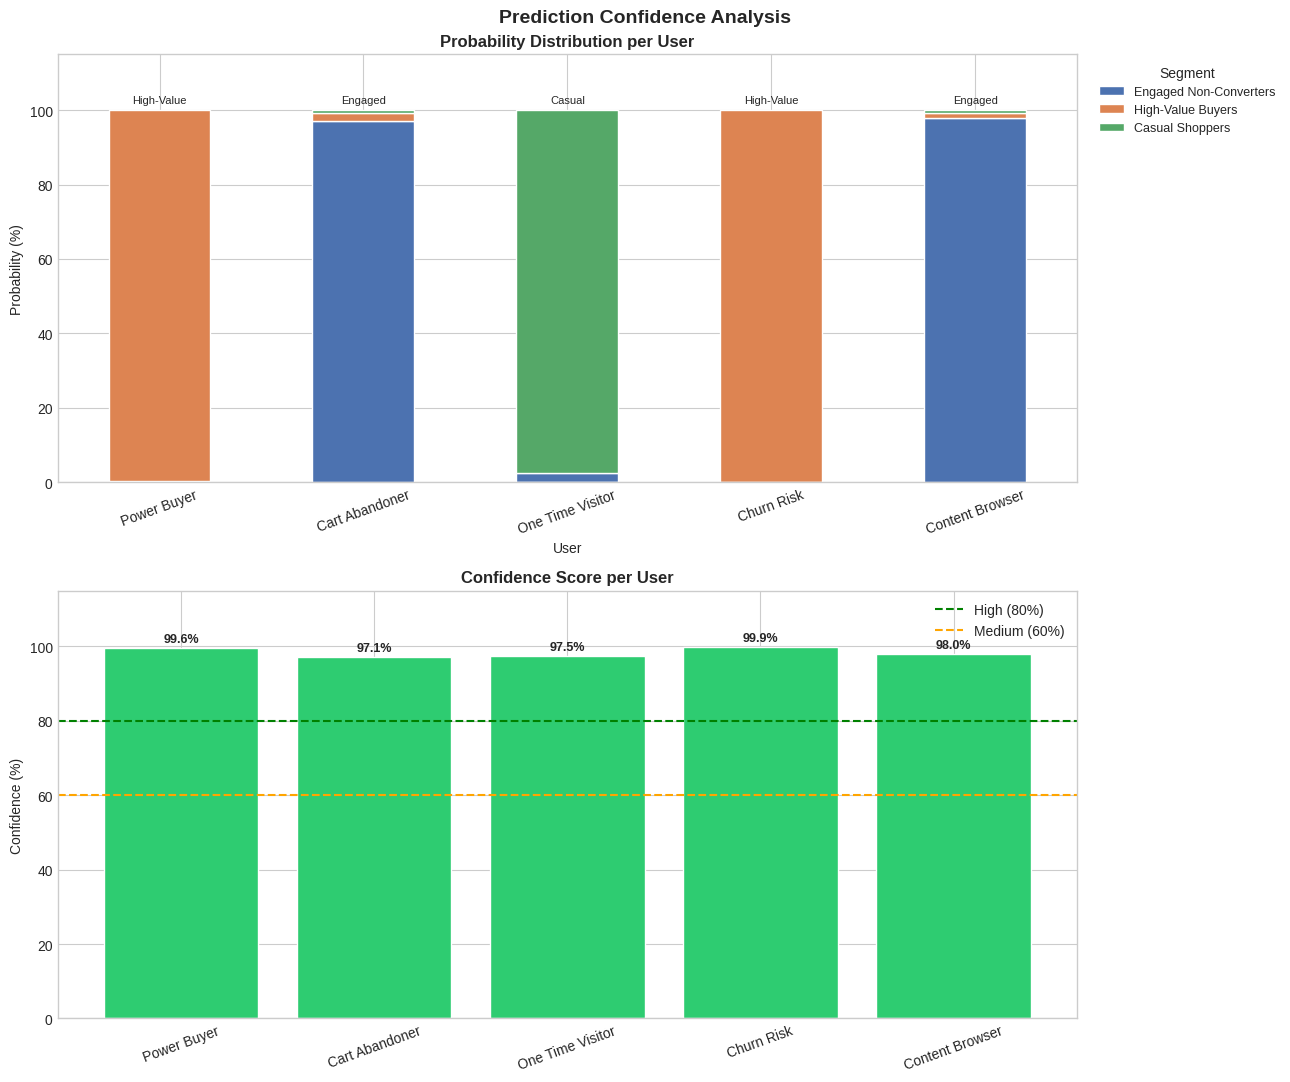

✅ Confidence visualization complete!


In [ ]:
# ─────────────────────────────────────────────────────────────
#  CONFIDENCE SCORES VISUALIZATION
# ─────────────────────────────────────────────────────────────

prob_rows = []
for user_id, result in single_results.items():
    row = {'User': user_id}
    row.update(result['all_probabilities'])
    row['Predicted']  = result['segment_name']
    row['Confidence'] = result['confidence']
    prob_rows.append(row)

prob_df  = pd.DataFrame(prob_rows).set_index('User')
seg_cols = [c for c in prob_df.columns if c not in ['Predicted', 'Confidence']]

fig, axes = plt.subplots(2, 1, figsize=(13, 11))
fig.suptitle('Prediction Confidence Analysis', fontsize=14, fontweight='bold')

# Stacked bar
colors_list = [PALETTE[i % len(PALETTE)] for i in range(len(seg_cols))]
prob_df[seg_cols].plot(kind='bar', stacked=True, ax=axes[0],
                       color=colors_list, edgecolor='white')
axes[0].set_title('Probability Distribution per User', fontweight='bold')
axes[0].set_ylabel('Probability (%)')
axes[0].set_ylim(0, 115)
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='Segment', bbox_to_anchor=(1.01, 1),
               loc='upper left', fontsize=9)
for i, (user, row) in enumerate(prob_df.iterrows()):
    axes[0].text(i, 102, row['Predicted'].split()[0],
                 ha='center', fontsize=8)

# Confidence bars
conf_vals  = prob_df['Confidence'].values
bar_colors = ['#2ecc71' if v >= 80 else '#f39c12' if v >= 60 else '#e74c3c'
              for v in conf_vals]
bars = axes[1].bar(prob_df.index, conf_vals,
                   color=bar_colors, edgecolor='white')
axes[1].axhline(y=80, color='green',  linestyle='--', label='High (80%)')
axes[1].axhline(y=60, color='orange', linestyle='--', label='Medium (60%)')
axes[1].set_title('Confidence Score per User', fontweight='bold')
axes[1].set_ylabel('Confidence (%)')
axes[1].set_ylim(0, 115)
axes[1].legend()
axes[1].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, conf_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1.5,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(SAVE_PATH + 'confidence_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confidence visualization complete!")

In [ ]:
# ─────────────────────────────────────────────────────────────
#  BATCH PREDICTION — 500 NEW USERS
# ─────────────────────────────────────────────────────────────

def predict_batch(df_input):
    df_input = df_input.copy()
    for col in FEATURE_COLS:
        if col not in df_input.columns:
            df_input[col] = 0
    X = df_input[FEATURE_COLS].fillna(0).clip(lower=0).copy()
    for col in LOG_COLS:
        X[col] = np.log1p(X[col])
    X_scaled      = scaler.transform(X)
    segment_ids   = rf_clf.predict(X_scaled)
    probabilities = rf_clf.predict_proba(X_scaled)
    df_input['predicted_segment'] = [segment_map.get(s, f'Cluster {s}')
                                      for s in segment_ids]
    df_input['confidence']        = (probabilities.max(axis=1) * 100).round(2)
    return df_input

# Generate 500 synthetic new users
np.random.seed(42)
N         = 500
sessions  = np.random.randint(1, 25, N)
pageviews = sessions * np.random.randint(2, 12, N)
scrolls   = (pageviews * np.random.uniform(0.2, 0.9, N)).astype(int)
view_items= (sessions  * np.random.uniform(0, 6,   N)).astype(int)
add_cart  = (view_items * np.random.uniform(0, 0.4, N)).astype(int)
checkout  = (add_cart   * np.random.uniform(0, 0.7, N)).astype(int)
purchases = (checkout   * np.random.uniform(0, 0.9, N)).astype(int)
revenue   = purchases   * np.random.uniform(20, 150, N)

df_batch = pd.DataFrame({
    'user_id'                   : [f'new_{i:04d}' for i in range(N)],
    'total_sessions'            : sessions,
    'total_pageviews'           : pageviews,
    'total_scrolls'             : scrolls,
    'active_days'               : np.clip(sessions - np.random.randint(0, 3, N), 1, None),
    'pages_per_session'         : np.round(pageviews / sessions, 2),
    'avg_session_duration_secs' : np.random.randint(30, 900, N),
    'scroll_rate'               : np.round(scrolls / (pageviews + 1), 3),
    'view_item_count'           : view_items,
    'add_to_cart_count'         : add_cart,
    'begin_checkout_count'      : checkout,
    'purchase_count'            : purchases,
    'cart_rate'                 : np.round(add_cart / (view_items + 1), 3),
    'checkout_rate'             : np.round(checkout / (add_cart + 1), 3),
    'conversion_rate'           : np.round(purchases / (sessions + 1), 3),
    'total_revenue'             : np.round(revenue, 2),
    'avg_order_value'           : np.round(revenue / (purchases + 1), 2),
    'total_items_purchased'     : purchases * np.random.randint(1, 4, N),
    'recency_days'              : np.random.randint(1, 60, N),
    'is_new_user'               : np.random.choice([0, 1], N, p=[0.6, 0.4]),
    'device_encoded'            : np.random.choice([0, 1, 2], N),
    'medium_encoded'            : np.random.choice([0, 1, 2, 3, 4], N)
})

df_predicted = predict_batch(df_batch)
df_predicted.to_csv(SAVE_PATH + 'batch_predictions.csv', index=False)

print("Batch Prediction — Segment Distribution:")
seg_counts = df_predicted['predicted_segment'].value_counts()
for seg, count in seg_counts.items():
    pct = count / len(df_predicted) * 100
    bar = '█' * int(pct / 3)
    print(f"  {seg:<28} {count:4d} ({pct:.1f}%)  {bar}")

print(f"\nAvg confidence : {df_predicted['confidence'].mean():.1f}%")
print(f"High (>80%)    : {(df_predicted['confidence'] >= 80).sum():,} users")
print(f"Low  (<60%)    : {(df_predicted['confidence'] < 60).sum():,} users")
print(f"\n✅ Saved → {SAVE_PATH}batch_predictions.csv")

Batch Prediction — Segment Distribution:
  Engaged Non-Converters        361 (72.2%)  ████████████████████████
  High-Value Buyers             122 (24.4%)  ████████
  Casual Shoppers                17 (3.4%)  █

Avg confidence : 95.8%
High (>80%)    : 474 users
Low  (<60%)    : 4 users

✅ Saved → /content/batch_predictions.csv


SIM 1: Cart Abandoner — what if they make purchases?


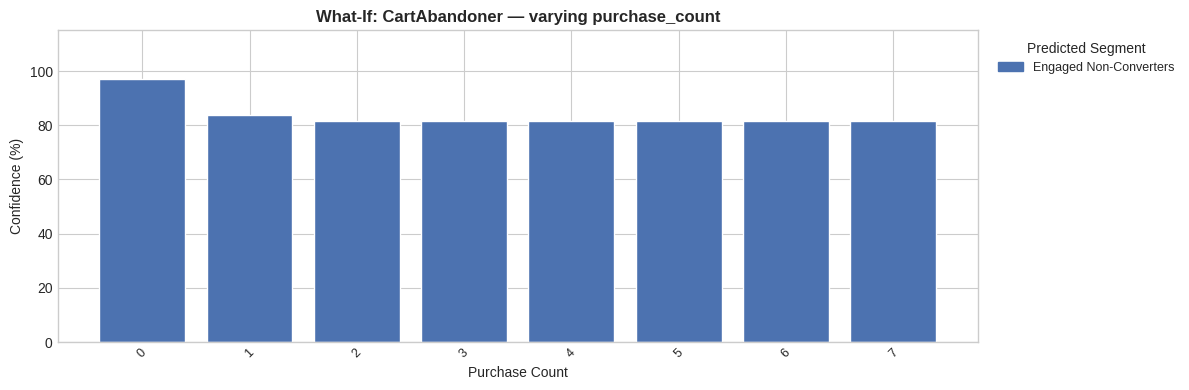


What-If: CartAbandoner — 'purchase_count'
     Value  Predicted Segment             Confidence
───────────────────────────────────────────────────────
         0  Engaged Non-Converters             97.1%
         1  Engaged Non-Converters             83.7%
         2  Engaged Non-Converters             81.7%
         3  Engaged Non-Converters             81.7%
         4  Engaged Non-Converters             81.7%
         5  Engaged Non-Converters             81.7%
         6  Engaged Non-Converters             81.7%
         7  Engaged Non-Converters             81.7%

SIM 2: One-Time Visitor — more sessions = new segment?


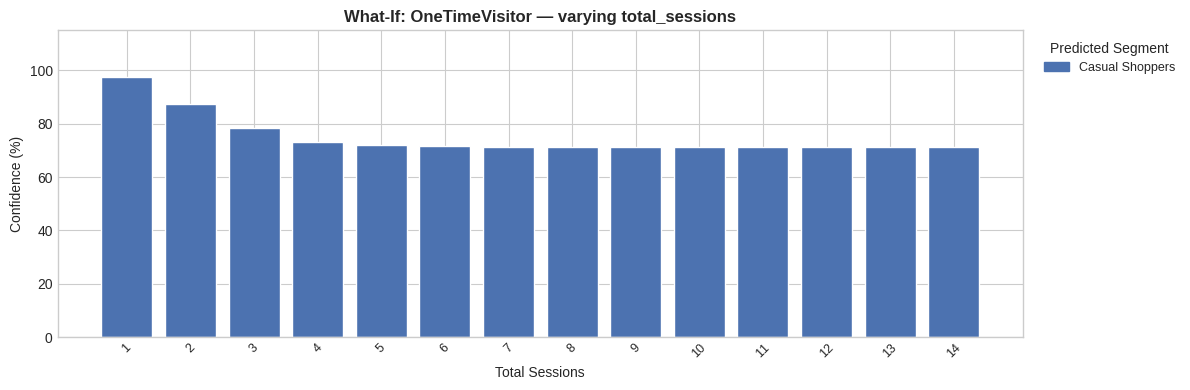


What-If: OneTimeVisitor — 'total_sessions'
     Value  Predicted Segment             Confidence
───────────────────────────────────────────────────────
         1  Casual Shoppers                    97.5%
         2  Casual Shoppers                    87.4%
         3  Casual Shoppers                    78.6%
         4  Casual Shoppers                    73.2%
         5  Casual Shoppers                    71.9%
         6  Casual Shoppers                    71.7%
         7  Casual Shoppers                    71.4%
         8  Casual Shoppers                    71.4%
         9  Casual Shoppers                    71.4%
        10  Casual Shoppers                    71.4%
        11  Casual Shoppers                    71.4%
        12  Casual Shoppers                    71.4%
        13  Casual Shoppers                    71.4%
        14  Casual Shoppers                    71.4%

SIM 3: Churn Risk — how does recency affect segment?


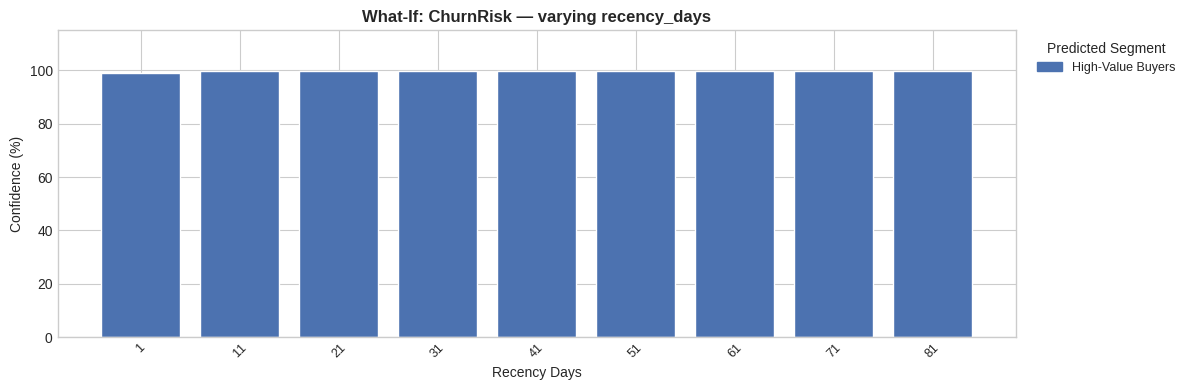


What-If: ChurnRisk — 'recency_days'
     Value  Predicted Segment             Confidence
───────────────────────────────────────────────────────
         1  High-Value Buyers                  99.2%
        11  High-Value Buyers                  99.9%
        21  High-Value Buyers                  99.9%
        31  High-Value Buyers                  99.9%
        41  High-Value Buyers                  99.9%
        51  High-Value Buyers                  99.9%
        61  High-Value Buyers                  99.9%
        71  High-Value Buyers                  99.9%
        81  High-Value Buyers                  99.8%

═══════════════════════════════════════════════════════
  ✅ ALL PREDICTION CELLS COMPLETE
═══════════════════════════════════════════════════════
  Single predictions  : 5 users
  Batch predictions   : 500 users
  What-If simulations : 3
  All files saved →   : /content/
═══════════════════════════════════════════════════════


In [ ]:
# ─────────────────────────────────────────────────────────────
#  WHAT-IF BEHAVIOR SIMULATOR
# ─────────────────────────────────────────────────────────────

def whatif_sweep(base_user, feature_name, sweep_values, user_label='User'):
    rows = []
    for val in sweep_values:
        modified = base_user.copy()
        modified[feature_name] = val
        result = predict_single_user(modified, verbose=False)
        rows.append({
            'feature_value'     : val,
            'predicted_segment' : result['segment_name'],
            'confidence'        : result['confidence']
        })
    df_sweep = pd.DataFrame(rows)

    # Plot
    unique_segs  = df_sweep['predicted_segment'].unique()
    color_map    = {s: PALETTE[i % len(PALETTE)] for i, s in enumerate(unique_segs)}
    bar_colors   = [color_map[s] for s in df_sweep['predicted_segment']]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(range(len(sweep_values)), df_sweep['confidence'],
           color=bar_colors, edgecolor='white')
    ax.set_xticks(range(len(sweep_values)))
    ax.set_xticklabels(sweep_values, rotation=45, fontsize=9)
    ax.set_title(f'What-If: {user_label} — varying {feature_name}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel(feature_name.replace('_', ' ').title())
    ax.set_ylabel('Confidence (%)')
    ax.set_ylim(0, 115)

    # Mark segment changes with vertical red line
    prev = None
    for i, row in df_sweep.iterrows():
        if row['predicted_segment'] != prev and prev is not None:
            ax.axvline(x=i - 0.5, color='red', linestyle='--',
                       linewidth=1.5, label='Segment change')
        prev = row['predicted_segment']

    # Legend for segment colors
    handles = [plt.Rectangle((0, 0), 1, 1, color=c, label=s)
               for s, c in color_map.items()]
    ax.legend(handles=handles, title='Predicted Segment',
              bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

    plt.tight_layout()
    plt.savefig(SAVE_PATH + f'whatif_{user_label}_{feature_name}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # Print table
    print(f"\nWhat-If: {user_label} — '{feature_name}'")
    print(f"{'Value':>10}  {'Predicted Segment':<28}  {'Confidence':>10}")
    print("─" * 55)
    prev = None
    for _, row in df_sweep.iterrows():
        change = ' ← SEGMENT CHANGE' if row['predicted_segment'] != prev and prev else ''
        print(f"{str(row['feature_value']):>10}  "
              f"{row['predicted_segment']:<28}  "
              f"{row['confidence']:>9.1f}%{change}")
        prev = row['predicted_segment']

    return df_sweep


# ── Run 3 simulations
print("=" * 55)
print("SIM 1: Cart Abandoner — what if they make purchases?")
print("=" * 55)
df_sim1 = whatif_sweep(
    test_users['Cart Abandoner'], 'purchase_count',
    list(range(0, 8)), 'CartAbandoner'
)

print("\n" + "=" * 55)
print("SIM 2: One-Time Visitor — more sessions = new segment?")
print("=" * 55)
df_sim2 = whatif_sweep(
    test_users['One Time Visitor'], 'total_sessions',
    list(range(1, 15)), 'OneTimeVisitor'
)

print("\n" + "=" * 55)
print("SIM 3: Churn Risk — how does recency affect segment?")
print("=" * 55)
df_sim3 = whatif_sweep(
    test_users['Churn Risk'], 'recency_days',
    list(range(1, 91, 10)), 'ChurnRisk'
)

print("\n" + "═" * 55)
print("  ✅ ALL PREDICTION CELLS COMPLETE")
print("═" * 55)
print(f"  Single predictions  : {len(test_users)} users")
print(f"  Batch predictions   : 500 users")
print(f"  What-If simulations : 3")
print(f"  All files saved →   : {SAVE_PATH}")
print("═" * 55)